# train an agent to play Ms. Pac-Man

**Choose three numbers. Run the notebook. Watch what the agent learns.**

The agent sees the game screen, chooses a move, and receives a reward from the game.
A neural network learns a value for each move through trial and error.

1. Open this notebook in Jupyter, VS Code, or Google Colab. In Colab, select **Runtime → Change runtime type → T4 GPU** if available.
2. Choose your three settings in the next cell.
3. Choose **Run All** (Colab: **Runtime → Run all**). Setup runs automatically. Local gameplay samples open above VS Code in a floating player at **4× speed**; a copy also appears inline.
4. Compare the five before/after scores and save your results.

If using Claude Code or Codex, ask it to run this notebook. The code tells it to ask you for your three choices before training.

A short run checks that everything works. Learning useful Atari behavior can take much longer; more episodes do not guarantee better play.

## 1. your three choices

| Setting | Meaning | Starting point |
|---|---|---|
| **Exploration** | Fraction of training moves chosen randomly. `0.20` means 20%. | `0.20` |
| **Episodes** | How many games to train on. Each game ends at game over or a fixed time limit. | `100` |
| **Learning rate** | How much the network changes at each update. | `0.0001` |

Change only the three numbers below. Try `5` episodes for a first check, then a longer run.
For this experiment, exploration stays **constant** so its meaning is easy to compare across runs.
The short replay warm-up uses random moves before learning starts.

In [1]:
# AI ASSISTANT INSTRUCTION:
# Before running training, ask the student:
# "Which exploration rate (0 to 1), number of episodes (positive whole number),
# and learning rate (greater than 0 and at most 1) do you want to use?"
# Explain the three choices briefly. Wait for their answer, then edit ONLY
# these three values. If they already chose values in this conversation,
# use those choices without asking again. Do not silently choose for them.
# The remaining cells are ready to run without student edits.

EXPLORATION = 0.1
EPISODES = 2000
LEARNING_RATE = 0.00025

### check the choices

These checks catch typos before a long experiment starts. They do not change your settings.

In [2]:
import math
assert (
    isinstance(EXPLORATION, (int, float))
    and not isinstance(EXPLORATION, bool)
    and math.isfinite(EXPLORATION) and 0 <= EXPLORATION <= 1
), "Exploration must be between 0 and 1."
assert (
    isinstance(EPISODES, int) and not isinstance(EPISODES, bool) and EPISODES > 0
), "Episodes must be a positive whole number."
assert (
    isinstance(LEARNING_RATE, (int, float))
    and not isinstance(LEARNING_RATE, bool)
    and math.isfinite(LEARNING_RATE) and 0 < LEARNING_RATE <= 1
), "Learning rate must be greater than 0 and at most 1."
print(f"Your experiment: {EXPLORATION:.0%} exploration, {EPISODES} episodes, learning rate {LEARNING_RATE:g}.")

Your experiment: 10% exploration, 2000 episodes, learning rate 0.00025.


## 2. automatic setup

Run this once per fresh session. It installs missing packages into the notebook's Python environment.
Python 3.11–3.13 is recommended. No separate game download is needed. For local popup playback, keep `pacman_player.py` next to this notebook and use a Python kernel with Tk (the local `py313` kernel supports it). Colab and machines without a desktop keep the fast inline preview.
If a package was already imported before an upgrade, restart the kernel and choose Run All again.

In [3]:
%pip -q install "torch>=2.6,<3" "gymnasium==1.3.0" "ale-py==0.11.2" "opencv-python-headless==4.14.0.94" "numpy>=2,<3" "matplotlib>=3.9,<4" "Pillow>=10,<13"

Note: you may need to restart the kernel to use updated packages.


### load the tools

Gymnasium runs the game, PyTorch learns from its screens, and Pillow saves gameplay. This cell also prints the actual Python and package versions, so runs can be compared.

In [4]:
import csv
import json
import platform
import random
import shutil
import time
from collections import deque
from datetime import datetime
from pathlib import Path
from importlib.metadata import version

import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from PIL import Image as PILImage
from IPython.display import Image, FileLink, display

gym.register_envs(ale_py)
# Keep CPU thread overhead manageable on laptops.
torch.set_num_threads(min(4, torch.get_num_threads()))


VERSIONS = {p: version(p) for p in ['torch', 'gymnasium', 'ale-py', 'opencv-python-headless', 'numpy', 'matplotlib', 'Pillow']}
print(f"Python {platform.python_version()} | {platform.platform()}")
print(VERSIONS)

Python 3.12.14 | macOS-15.6.1-arm64-arm-64bit
{'torch': '2.14.0', 'gymnasium': '1.3.0', 'ale-py': '0.11.2', 'opencv-python-headless': '4.14.0.94', 'numpy': '2.5.3', 'matplotlib': '3.11.2', 'Pillow': '12.3.0'}


### fixed experiment settings

These values keep experiments comparable. One **decision** advances four game frames. The agent remembers 5,000 past decisions and learns from 32 at a time. The first 1,000 decisions collect experience; after that, learning happens every four decisions. You only need to edit the three choices in section 1.

In [5]:
# Fixed classroom settings. Students only need the three choices above.
SEED = 42
MAX_STEPS = 3000          # Agent decisions per game, about 200 seconds of game time.
FRAME_SKIP = 4           # Four emulator frames per agent decision, applied once.
REPLAY_CAPACITY = 50000  # Raised from the default 5,000; see README.
                         # 5,000 transitions hold only ~7 games, so every sampled
                         # batch is heavily correlated. ~1.65 GiB of pixel data.
BATCH_SIZE = 32
WARMUP_STEPS = 1000      # Random-action collection before any weight updates.
TRAIN_EVERY = 4          # One update every four training decisions.
TARGET_EVERY = 1000      # Copy learned weights to target every 1,000 decisions.
GAMMA = 0.99             # How much future rewards count.
DEMO_EVERY = 25          # Episodes between gameplay demonstrations.
EVAL_SEEDS = [101, 202, 303, 404, 505]
EVAL_EXPLORATION = 0.05  # Identical before/after; independent of training choice.


### faster sample playback

Samples play **4× faster**: 20 seconds of game time takes about five seconds to watch. We save every fourth preview frame and keep a normal display interval, avoiding tiny GIF delays that viewers often clamp. This only changes the recording and playback; every game decision still runs normally.

Local samples open automatically in an **always-on-top popup** with Pause, Replay, and a pin toggle. Each sample plays exactly twice and stops on its final frame. Replay starts two more plays. Closing the popup leaves training running. Set `SHOW_POPUPS = False` for inline playback only.

In [6]:
PREVIEW_SPEED = 4
PREVIEW_PLAYS = 2
SHOW_POPUPS = False  # Headless run; inline GIFs only.
PREVIEW_SECONDS = 20
PREVIEW_STRIDE = PREVIEW_SPEED
PREVIEW_DECISIONS = round(PREVIEW_SECONDS * 60 / FRAME_SKIP)
PREVIEW_FRAME_MS = round(1000 * FRAME_SKIP / 60)

## 3. the game and the learning rule

The network sees **four grayscale 84 × 84 screens** so it can infer movement.
Its outputs are estimated future rewards for the available moves, not probabilities.

The agent keeps past experiences in a small replay memory. It samples them to update the network.
A second, slower-changing network supplies the learning target:

**target = reward + discounted value of the next screen**

At game over, there is no future reward. At a time limit, the game could have continued, so we keep the future-value term.
Learning uses rewards clipped to −1 through +1; every score you see is the **original game score**.
The implementation below is ready to use. You do not need to edit it.

### 3a. turn game screens into observations

Start Ms. Pac-Man, reduce each screen to 84 × 84 grayscale pixels, and stack four screens. A single image shows position; a short sequence also reveals movement. Reset starts with four copies of the new game screen.

In [7]:
def make_env():
    env = gym.make("ALE/MsPacman-v5", frameskip=1,
                   repeat_action_probability=0.25, render_mode="rgb_array")
    env = gym.wrappers.AtariPreprocessing(
        env, noop_max=30, frame_skip=FRAME_SKIP, screen_size=84,
        terminal_on_life_loss=False, grayscale_obs=True, scale_obs=False)
    env = gym.wrappers.FrameStackObservation(env, stack_size=4, padding_type="reset")
    return gym.wrappers.TimeLimit(env, max_episode_steps=MAX_STEPS)

### 3b. estimate the value of each move

The convolution layers look for patterns in the screens. The final layer produces one number per move: its estimated future reward. `forward` scales pixel values from 0–255 to 0–1 before using them.

In [8]:
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        # Read visual patterns, then produce one value per available move.
        self.layers = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU(),
            nn.Flatten(), nn.Linear(3136, 512), nn.ReLU(),
            nn.Linear(512, n_actions))

    def forward(self, screens):
        return self.layers(screens.float() / 255.0)

### 3c. remember past experience

Each memory stores the screen stack, move, reward, next screen, and whether the game ended. Random batches mix experiences from different moments. Consecutive stacks share three frames, so we only store the one new frame to save memory.

In [9]:
class ReplayMemory:
    def __init__(self, capacity):
        self.items = deque(maxlen=capacity)

    def add(self, obs, action, reward, next_obs, terminated, truncated):
        # The next stack is [obs[1], obs[2], obs[3], new_frame].
        # Store five frames instead of two overlapping four-frame stacks.
        self.items.append((np.array(obs, dtype=np.uint8, copy=True), action,
                           float(np.clip(reward, -1, 1)),
                           np.array(next_obs[-1], dtype=np.uint8, copy=True),
                           bool(terminated), bool(truncated)))

    def sample(self, size, rng):
        batch = rng.sample(list(self.items), size)
        obs, actions, rewards, last_frames, ended, truncated = zip(*batch)
        obs = np.stack(obs)
        next_obs = np.concatenate([obs[:, 1:], np.stack(last_frames)[:, None]], axis=1)
        return obs, np.array(actions), np.array(rewards, dtype=np.float32), next_obs, np.array(ended), np.array(truncated)

    def __len__(self):
        return len(self.items)

### 3d. choose a move

With probability `epsilon`, try a random move (**explore**). Otherwise choose the move with the highest predicted value (**exploit**). Choosing a move does not update the network.

In [10]:
@torch.no_grad()
def choose_action(model, obs, epsilon, rng, n_actions):
    if rng.random() < epsilon:
        return rng.randrange(n_actions)
    device = next(model.parameters()).device
    screens = torch.as_tensor(np.asarray(obs), device=device).unsqueeze(0)
    return int(model(screens).argmax(dim=1).item())

### 3e. learn from a batch

1. Predict the value of each remembered move.
2. Build a target from its reward plus the next screen’s estimated value.
3. Measure the prediction error and adjust the network.

The target network changes less often to give learning a steadier reference. True game over removes future reward; reaching the time limit does not.

In [11]:
def learn(model, target, optimizer, batch):
    device = next(model.parameters()).device
    obs, actions, rewards, next_obs, ended, truncated = [torch.as_tensor(x, device=device) for x in batch]
    # 1. What value did the network predict for the move we took?
    values = model(obs).gather(1, actions.long().unsqueeze(1)).squeeze(1)
    # 2. What target does the observed reward suggest?
    with torch.no_grad():
        # Mask true termination only. A time limit still allows bootstrapping.
        targets = rewards + GAMMA * (~ended).float() * target(next_obs).max(dim=1).values
    # 3. Reduce the gap between prediction and target.
    loss = nn.functional.smooth_l1_loss(values, targets)
    if not torch.isfinite(loss):
        raise RuntimeError("Loss became non-finite. Start a new run with a smaller learning rate.")
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 10.0, error_if_nonfinite=True)
    optimizer.step()
    return float(loss.item())

### 3f. select working hardware

Try CUDA, Apple MPS, then CPU. A real batch tests prediction, backward pass, and a weight update before we commit to that device.

In [12]:
def select_device(n_actions):
    candidates = []
    if torch.cuda.is_available():
        candidates.append("cuda")
    if torch.backends.mps.is_available():
        candidates.append("mps")
    candidates.append("cpu")
    for candidate in candidates:
        try:
            # Test the actual network, minibatch, backward pass, and optimizer.
            probe = DQN(n_actions).to(candidate)
            optimizer = torch.optim.Adam(probe.parameters(), lr=LEARNING_RATE)
            screens = np.zeros((BATCH_SIZE, 4, 84, 84), dtype=np.uint8)
            batch = (screens, np.zeros(BATCH_SIZE, dtype=np.int64),
                     np.ones(BATCH_SIZE, dtype=np.float32), screens,
                     np.zeros(BATCH_SIZE, dtype=bool), np.zeros(BATCH_SIZE, dtype=bool))
            learn(probe, probe, optimizer, batch)
            print(f"Using {candidate.upper()}; training-batch check passed.")
            return torch.device(candidate)
        except RuntimeError as error:
            if candidate == "cpu":
                raise
            print(f"{candidate.upper()} check failed ({error}). Trying the next device.")

### check the first screen

Create the game, check the four-screen stack, and show the available joystick moves. If this cell succeeds, the game and learning hardware are ready.

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Using MPS; training-batch check passed.
Available moves: ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']


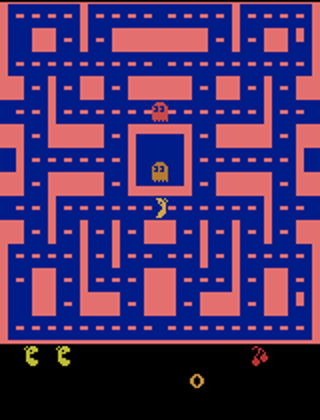

Replay pixel budget: 1682 MiB, plus model and batch memory.


In [13]:
probe_env = make_env()
try:
    probe_obs, _ = probe_env.reset(seed=SEED)
    assert probe_obs.shape == (4, 84, 84) and probe_obs.dtype == np.uint8
    assert all(np.array_equal(probe_obs[0], frame) for frame in probe_obs)
    N_ACTIONS = int(probe_env.action_space.n)
    DEVICE = select_device(N_ACTIONS)
    print("Available moves:", probe_env.unwrapped.get_action_meanings())
    display(PILImage.fromarray(probe_env.render()).resize((320, 420)))
finally:
    probe_env.close()
print(f"Replay pixel budget: {REPLAY_CAPACITY * 5 * 84 * 84 / 2**20:.0f} MiB, plus model and batch memory.")

## 4. gameplay, scores, and saved results

Evaluation uses a separate game environment and the same five seeds before and after training.
It uses 5% random moves in both cases. Evaluation never changes the network or training memory.
The baseline is an **untrained network**, not a random-action agent.

GIFs show the first 20 seconds at most, compressed to about five seconds at 4× speed; the reported score covers the entire evaluated game, up to the fixed time limit.

### 4a. score complete games and record a short sample

All evaluation games run at full computing speed, with no waiting for playback. We record a short excerpt, but add rewards for the **entire game**. For the final preview we keep the excerpt from the game with the highest full-game score.

In [14]:
def evaluate(model, seeds, gif_path=None, record_best=False):
    env = make_env()
    scores, lengths, capped = [], [], []
    best_score, chosen_frames = -float("inf"), []
    was_training = model.training
    model.eval()
    try:
        for index, seed in enumerate(seeds):
            rng = random.Random(seed + 10000)
            obs, _ = env.reset(seed=seed)
            total, frames = 0.0, []
            capture = gif_path is not None and (record_best or index == 0)
            for step in range(MAX_STEPS):
                if capture and step < PREVIEW_DECISIONS and step % PREVIEW_STRIDE == 0:
                    frames.append(PILImage.fromarray(env.render()).copy())
                action = choose_action(model, obs, EVAL_EXPLORATION, rng, N_ACTIONS)
                obs, reward, ended, truncated, _ = env.step(action)
                total += reward
                if ended or truncated:
                    break
            scores.append(float(total))
            lengths.append(step + 1)
            capped.append(bool(truncated))
            if capture and (not record_best or total > best_score):
                chosen_frames, best_score = frames, total
    finally:
        env.close()
        model.train(was_training)
    if gif_path is not None and chosen_frames:
        chosen_frames[0].save(gif_path, save_all=True, append_images=chosen_frames[1:],
                              duration=PREVIEW_FRAME_MS, loop=PREVIEW_PLAYS - 1)
    return {"seeds": list(seeds), "scores": scores, "mean": float(np.mean(scores)),
            "steps": lengths, "time_limited": capped}

### 4b. show the sample

Always keep a playable GIF in the notebook. Both the inline GIF and the popup play exactly twice. When a local desktop and Tk are available, the separate floating player does not block the next learning update.

In [15]:
def show_sample(gif_path, label):
    """Display a recorded excerpt inline and, locally, above the notebook."""
    print(f"{label} | {PREVIEW_SPEED}× playback | {PREVIEW_PLAYS} plays | first {PREVIEW_SECONDS}s of game time")
    display(Image(filename=str(gif_path)))
    if not SHOW_POPUPS:
        return
    try:
        from pacman_player import show_popup
        opened = show_popup(gif_path, f"{label} · {PREVIEW_SPEED}× speed")
        if not opened:
            print("Popup unavailable in this kernel; use the fast inline preview.")
    except (ImportError, OSError) as error:
        print(f"Using the inline preview. Local popup helper unavailable: {error}")

### 4c. save a model for playback

A checkpoint stores the learned weights and action count. Reloading it lets us check the saved agent. It does not contain everything needed to resume the exact training session.

In [16]:
def save_checkpoint(model, path, episode, steps):
    # Portable playback checkpoint. This is not an exact training-resume snapshot:
    # replay, optimizer, and emulator state are intentionally not persisted.
    payload = {"model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
               "n_actions": N_ACTIONS, "episode": episode, "steps": steps,
               "exploration": EXPLORATION, "learning_rate": LEARNING_RATE}
    temporary = path.with_suffix(".tmp")
    torch.save(payload, temporary)
    temporary.replace(path)

### 4d. save one row per game

The CSV keeps each completed game’s raw score, decisions, exploration, loss, and elapsed time. A game with no learning updates has no meaningful loss yet.

In [17]:
def save_metrics(rows, path):
    fields = ["episode", "score", "steps", "total_steps", "exploration", "mean_loss", "elapsed_seconds", "terminated", "truncated"]
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)

### 4e. draw the learning dashboard

The three panels show scores, prediction error, and exploration. Look at game scores as well as loss: reducing prediction error does not guarantee better play.

In [18]:
def plot_training(rows, path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    if rows:
        episodes = [r["episode"] for r in rows]
        scores = [r["score"] for r in rows]
        smooth = [np.mean(scores[max(0, i - 24):i + 1]) for i in range(len(scores))]
        axes[0].plot(episodes, scores, alpha=0.35, label="Each training game")
        axes[0].plot(episodes, smooth, label="Up to 25-game average")
        axes[0].legend(fontsize=8)
        axes[1].plot(episodes, [r["mean_loss"] for r in rows])
        axes[2].plot(episodes, [r["exploration"] for r in rows])
    for ax, title in zip(axes, ["Raw training score", "Mean update loss", "Training exploration"]):
        ax.set(title=title, xlabel="Completed episode")
        ax.grid(alpha=0.2)
    axes[2].set_ylim(0, 1.05)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)

## 5. train your agent

The setup cell below starts a **fresh experiment** each time, using your three choices.
It saves the untrained baseline, trains, and prints a line after each episode plus a progress update every 500 decisions.
Every 25 episodes it opens a fast gameplay sample and saves a checkpoint and plot.

To stop early, use the notebook's **Interrupt / Stop** button once. The current model and completed-episode results are saved.
Then run the remaining cells to evaluate and download them. A run ending before warm-up finishes has no learning updates yet.
Each run has its own folder so earlier experiments stay available.

### 5a. start a fresh experiment

Create the two networks, empty replay memory, random seeds, and a unique results folder. This cell resets training. To try again, rerun from here or choose Run All.

In [19]:
# Each execution starts fresh, including network weights and replay memory.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
train_rng = random.Random(SEED)
replay_rng = random.Random(SEED + 1)
RUN_DIR = Path("pacman_runs") / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
RUN_DIR.mkdir(parents=True, exist_ok=False)
(RUN_DIR / "demos").mkdir()
model = DQN(N_ACTIONS).to(DEVICE)
target = DQN(N_ACTIONS).to(DEVICE)
target.load_state_dict(model.state_dict())
target.eval()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
replay = ReplayMemory(REPLAY_CAPACITY)
history, demo_history = [], []
total_steps, completed_episodes, updates = 0, 0, 0

_training_started = False

### 5b. record the settings and test saving

Save the hardware and settings alongside the initial weights. Reload those weights immediately to catch any checkpoint problem before training.

In [20]:
config = {"exploration": EXPLORATION, "episodes_requested": EPISODES, "learning_rate": LEARNING_RATE,
          "seed": SEED, "device": str(DEVICE), "python": platform.python_version(),
          "platform": platform.platform(), "packages": VERSIONS,
          "environment": "ALE/MsPacman-v5", "frame_skip": FRAME_SKIP,
          "sticky_action_probability": 0.25, "noop_max": 30, "grayscale_size": 84,
          "stack_size": 4, "terminal_on_life_loss": False, "max_decisions_per_game": MAX_STEPS,
          "replay_capacity": REPLAY_CAPACITY, "warmup_decisions": WARMUP_STEPS,
          "batch_size": BATCH_SIZE, "train_every_decisions": TRAIN_EVERY,
          "target_sync_decisions": TARGET_EVERY, "gamma": GAMMA,
          "training_reward_clipping": [-1, 1], "eval_exploration": EVAL_EXPLORATION,
          "eval_seeds": EVAL_SEEDS, "preview_seconds": PREVIEW_SECONDS,
          "preview_speed": PREVIEW_SPEED, "preview_plays": PREVIEW_PLAYS,
          "preview_stride": PREVIEW_STRIDE,
          "preview_frame_ms": PREVIEW_FRAME_MS}
(RUN_DIR / "config.json").write_text(json.dumps(config, indent=2))
save_checkpoint(model, RUN_DIR / "untrained.pt", 0, 0)
# Check saving and loading before starting the long run.
roundtrip = torch.load(RUN_DIR / "untrained.pt", map_location="cpu", weights_only=True)
assert all(torch.equal(v.cpu(), roundtrip["model"][k]) for k, v in model.state_dict().items())
del roundtrip

### 5c. measure the starting point

Play five games before learning. This gives a baseline for the final comparison. The popup shows a short, accelerated excerpt from the first game.

Evaluating the untrained network on five games. This can take a few minutes.


Before training: [350.0, 500.0, 320.0, 800.0, 490.0] | mean: 492.0
Before training | 4× playback | 2 plays | first 20s of game time


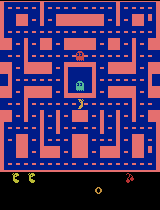

In [21]:
print("Evaluating the untrained network on five games. This can take a few minutes.", flush=True)
baseline = evaluate(model, EVAL_SEEDS, RUN_DIR / "demos" / "episode_0000.gif")
(RUN_DIR / "baseline.json").write_text(json.dumps(baseline, indent=2))
print("Before training:", baseline["scores"], "| mean:", baseline["mean"])
show_sample(RUN_DIR / "demos" / "episode_0000.gif", "Before training")

### 5d. learn during one game

Repeat **choose → play → remember → learn** until game over or the time limit. The counters span all games, so warm-up happens once. Every 1,000 decisions, copy the learning network into the target network.

In [22]:
def train_one_episode(train_env, episode):
    """Collect experience and update the agent during one complete game."""
    global total_steps, updates
    obs, _ = train_env.reset(seed=SEED + episode)
    score, losses = 0.0, []
    for step in range(MAX_STEPS):
        epsilon = 1.0 if total_steps < WARMUP_STEPS else EXPLORATION
        action = choose_action(model, obs, epsilon, train_rng, N_ACTIONS)
        next_obs, reward, ended, truncated, _ = train_env.step(action)
        replay.add(obs, action, reward, next_obs, ended, truncated)
        obs = next_obs
        score += reward
        total_steps += 1
        if total_steps >= WARMUP_STEPS and len(replay) >= BATCH_SIZE and total_steps % TRAIN_EVERY == 0:
            losses.append(learn(model, target, optimizer, replay.sample(BATCH_SIZE, replay_rng)))
            updates += 1
        if total_steps % TARGET_EVERY == 0:
            target.load_state_dict(model.state_dict())
        if total_steps % 500 == 0:
            elapsed = time.monotonic() - started
            print(f"  Episode {episode}/{EPISODES} | {total_steps:,} decisions | {updates:,} updates | {elapsed / 60:.1f} min", flush=True)
        if ended or truncated:
            break
    return {"episode": episode, "score": float(score), "steps": step + 1,
            "total_steps": total_steps, "exploration": epsilon,
            "mean_loss": float(np.mean(losses)) if losses else float("nan"),
            "elapsed_seconds": time.monotonic() - started,
            "terminated": bool(ended), "truncated": bool(truncated)}

### 5e. save a progress sample

Every 25 completed games, evaluate on a separate game, show the fast popup, and save a checkpoint. Evaluation does not add experiences to replay or change weights.

In [23]:
def save_progress_sample(episode):
    gif_path = RUN_DIR / "demos" / f"episode_{episode:04d}.gif"
    demo = evaluate(model, EVAL_SEEDS[:1], gif_path)
    demo_history.append({"episode": episode, **demo})
    (RUN_DIR / "demo_scores.json").write_text(json.dumps(demo_history, indent=2))
    print("Separate demonstration score:", demo["scores"][0])
    save_checkpoint(model, RUN_DIR / f"episode_{episode:04d}.pt", episode, total_steps)
    plot_training(history, RUN_DIR / "training_dashboard.png")
    show_sample(gif_path, f"After {episode} training games")

### 5f. save the current result

Run this helper on completion, interruption, or failure. Checkpoints include all weight updates so far; the CSV contains completed games only.

In [24]:
def save_training_result(status):
    save_checkpoint(model, RUN_DIR / "trained.pt", completed_episodes, total_steps)
    save_metrics(history, RUN_DIR / "training.csv")
    plot_training(history, RUN_DIR / "training_dashboard.png")
    summary = {"status": status, "completed_episodes": completed_episodes,
               "total_decisions": total_steps, "learning_updates": updates,
               "elapsed_seconds_including_periodic_demos": time.monotonic() - started}
    (RUN_DIR / "training_summary.json").write_text(json.dumps(summary, indent=2))

### 5g. run the training games

This is the experiment loop. Each call plays one game and prints its score. **Interrupt / Stop** saves the current model; then continue to section 6. To start another experiment, rerun from 5a so the model, baseline, and results folder all reset together.

Episode 1/2000 | score 130 | recent mean 130.0 | exploration 100%


  Episode 2/2000 | 500 decisions | 0 updates | 0.0 min


  Episode 2/2000 | 1,000 decisions | 1 updates | 0.0 min


Episode 2/2000 | score 410 | recent mean 270.0 | exploration 10%


  Episode 3/2000 | 1,500 decisions | 126 updates | 0.0 min


...

  Episode 24/2000 | 13,500 decisions | 3,126 updates | 1.1 min


Episode 24/2000 | score 690 | recent mean 550.0 | exploration 10%


  Episode 25/2000 | 14,000 decisions | 3,251 updates | 1.1 min


Episode 25/2000 | score 620 | recent mean 552.8 | exploration 10%


Separate demonstration score: 500.0
After 25 training games | 4× playback | 2 plays | first 20s of game time


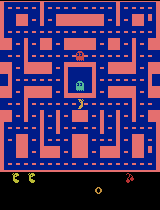

  Episode 26/2000 | 14,500 decisions | 3,376 updates | 1.2 min


Episode 26/2000 | score 380 | recent mean 562.8 | exploration 10%


  Episode 27/2000 | 15,000 decisions | 3,501 updates | 1.2 min


Episode 27/2000 | score 530 | recent mean 567.6 | exploration 10%


  Episode 28/2000 | 15,500 decisions | 3,626 updates | 1.3 min


...

Episode 49/2000 | score 370 | recent mean 589.6 | exploration 10%


  Episode 50/2000 | 27,500 decisions | 6,626 updates | 2.0 min


  Episode 50/2000 | 28,000 decisions | 6,751 updates | 2.1 min


Episode 50/2000 | score 1040 | recent mean 606.4 | exploration 10%


Separate demonstration score: 350.0
After 50 training games | 4× playback | 2 plays | first 20s of game time


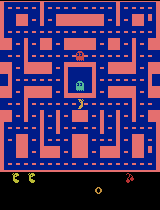

  Episode 51/2000 | 28,500 decisions | 6,876 updates | 2.1 min


Episode 51/2000 | score 680 | recent mean 618.4 | exploration 10%


  Episode 52/2000 | 29,000 decisions | 7,001 updates | 2.2 min


Episode 52/2000 | score 420 | recent mean 614.0 | exploration 10%


  Episode 53/2000 | 29,500 decisions | 7,126 updates | 2.2 min


...

Episode 74/2000 | score 1720 | recent mean 780.0 | exploration 10%


  Episode 75/2000 | 42,500 decisions | 10,376 updates | 3.0 min


  Episode 75/2000 | 43,000 decisions | 10,501 updates | 3.0 min


Episode 75/2000 | score 460 | recent mean 756.8 | exploration 10%


Separate demonstration score: 340.0
After 75 training games | 4× playback | 2 plays | first 20s of game time


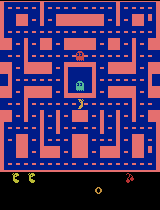

Episode 76/2000 | score 470 | recent mean 748.4 | exploration 10%


  Episode 77/2000 | 43,500 decisions | 10,626 updates | 3.1 min


  Episode 77/2000 | 44,000 decisions | 10,751 updates | 3.1 min


Episode 77/2000 | score 630 | recent mean 756.8 | exploration 10%


  Episode 78/2000 | 44,500 decisions | 10,876 updates | 3.1 min


...

  Episode 99/2000 | 56,000 decisions | 13,751 updates | 4.0 min


Episode 99/2000 | score 880 | recent mean 579.2 | exploration 10%


  Episode 100/2000 | 56,500 decisions | 13,876 updates | 4.0 min


Episode 100/2000 | score 560 | recent mean 583.2 | exploration 10%


Separate demonstration score: 820.0
After 100 training games | 4× playback | 2 plays | first 20s of game time


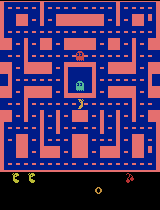

  Episode 101/2000 | 57,000 decisions | 14,001 updates | 4.1 min


Episode 101/2000 | score 830 | recent mean 597.6 | exploration 10%


  Episode 102/2000 | 57,500 decisions | 14,126 updates | 4.1 min


Episode 102/2000 | score 410 | recent mean 588.8 | exploration 10%


  Episode 103/2000 | 58,000 decisions | 14,251 updates | 4.1 min


...

  Episode 124/2000 | 71,000 decisions | 17,501 updates | 5.0 min


Episode 124/2000 | score 740 | recent mean 742.4 | exploration 10%


  Episode 125/2000 | 71,500 decisions | 17,626 updates | 5.0 min


Episode 125/2000 | score 230 | recent mean 729.2 | exploration 10%


Separate demonstration score: 360.0
After 125 training games | 4× playback | 2 plays | first 20s of game time


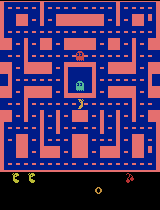

  Episode 126/2000 | 72,000 decisions | 17,751 updates | 5.1 min


Episode 126/2000 | score 590 | recent mean 719.6 | exploration 10%


  Episode 127/2000 | 72,500 decisions | 17,876 updates | 5.1 min


Episode 127/2000 | score 410 | recent mean 719.6 | exploration 10%


  Episode 128/2000 | 73,000 decisions | 18,001 updates | 5.1 min


...

  Episode 149/2000 | 85,000 decisions | 21,001 updates | 6.3 min


Episode 149/2000 | score 770 | recent mean 673.2 | exploration 10%


  Episode 150/2000 | 85,500 decisions | 21,126 updates | 6.3 min


Episode 150/2000 | score 270 | recent mean 674.8 | exploration 10%


Separate demonstration score: 490.0
After 150 training games | 4× playback | 2 plays | first 20s of game time


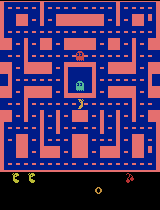

  Episode 151/2000 | 86,000 decisions | 21,251 updates | 6.4 min


Episode 151/2000 | score 250 | recent mean 661.2 | exploration 10%


  Episode 152/2000 | 86,500 decisions | 21,376 updates | 6.5 min


  Episode 152/2000 | 87,000 decisions | 21,501 updates | 6.5 min


Episode 152/2000 | score 1300 | recent mean 696.8 | exploration 10%


...

Episode 174/2000 | score 590 | recent mean 579.6 | exploration 10%


  Episode 175/2000 | 99,000 decisions | 24,501 updates | 7.6 min


  Episode 175/2000 | 99,500 decisions | 24,626 updates | 7.7 min


Episode 175/2000 | score 810 | recent mean 601.2 | exploration 10%


Separate demonstration score: 240.0
After 175 training games | 4× playback | 2 plays | first 20s of game time


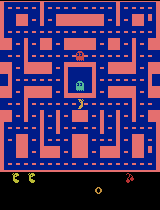

  Episode 176/2000 | 100,000 decisions | 24,751 updates | 7.7 min


Episode 176/2000 | score 350 | recent mean 605.2 | exploration 10%


  Episode 177/2000 | 100,500 decisions | 24,876 updates | 7.8 min


  Episode 177/2000 | 101,000 decisions | 25,001 updates | 7.8 min


Episode 177/2000 | score 1270 | recent mean 604.0 | exploration 10%


...

  Episode 199/2000 | 114,500 decisions | 28,376 updates | 9.1 min


Episode 199/2000 | score 830 | recent mean 760.4 | exploration 10%


  Episode 200/2000 | 115,000 decisions | 28,501 updates | 9.1 min


Episode 200/2000 | score 470 | recent mean 746.8 | exploration 10%


Separate demonstration score: 1230.0
After 200 training games | 4× playback | 2 plays | first 20s of game time


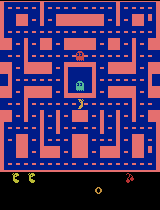

  Episode 201/2000 | 115,500 decisions | 28,626 updates | 9.2 min


Episode 201/2000 | score 530 | recent mean 754.0 | exploration 10%


  Episode 202/2000 | 116,000 decisions | 28,751 updates | 9.2 min


  Episode 202/2000 | 116,500 decisions | 28,876 updates | 9.3 min


Episode 202/2000 | score 680 | recent mean 730.4 | exploration 10%


...

  Episode 224/2000 | 129,500 decisions | 32,126 updates | 10.5 min


Episode 224/2000 | score 490 | recent mean 773.2 | exploration 10%


  Episode 225/2000 | 130,000 decisions | 32,251 updates | 10.5 min


Episode 225/2000 | score 450 | recent mean 772.4 | exploration 10%


Separate demonstration score: 270.0
After 225 training games | 4× playback | 2 plays | first 20s of game time


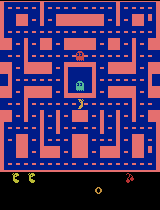

  Episode 226/2000 | 130,500 decisions | 32,376 updates | 10.6 min


  Episode 226/2000 | 131,000 decisions | 32,501 updates | 10.6 min


Episode 226/2000 | score 1460 | recent mean 809.6 | exploration 10%


  Episode 227/2000 | 131,500 decisions | 32,626 updates | 10.7 min


Episode 227/2000 | score 830 | recent mean 815.6 | exploration 10%


...

  Episode 249/2000 | 144,000 decisions | 35,751 updates | 11.8 min


  Episode 249/2000 | 144,500 decisions | 35,876 updates | 11.9 min


Episode 249/2000 | score 1290 | recent mean 710.8 | exploration 10%


Episode 250/2000 | score 310 | recent mean 705.2 | exploration 10%


Separate demonstration score: 940.0
After 250 training games | 4× playback | 2 plays | first 20s of game time


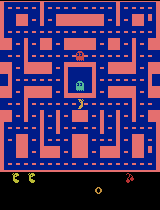

  Episode 251/2000 | 145,000 decisions | 36,001 updates | 11.9 min


Episode 251/2000 | score 300 | recent mean 658.8 | exploration 10%


  Episode 252/2000 | 145,500 decisions | 36,126 updates | 12.0 min


Episode 252/2000 | score 300 | recent mean 637.6 | exploration 10%


  Episode 253/2000 | 146,000 decisions | 36,251 updates | 12.1 min


...

  Episode 274/2000 | 159,000 decisions | 39,501 updates | 13.6 min


Episode 274/2000 | score 1050 | recent mean 719.2 | exploration 10%


  Episode 275/2000 | 159,500 decisions | 39,626 updates | 13.6 min


Episode 275/2000 | score 800 | recent mean 738.8 | exploration 10%


Separate demonstration score: 400.0
After 275 training games | 4× playback | 2 plays | first 20s of game time


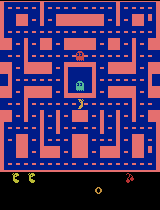

  Episode 276/2000 | 160,000 decisions | 39,751 updates | 13.7 min


  Episode 276/2000 | 160,500 decisions | 39,876 updates | 13.7 min


Episode 276/2000 | score 500 | recent mean 746.8 | exploration 10%


Episode 277/2000 | score 290 | recent mean 746.4 | exploration 10%


  Episode 278/2000 | 161,000 decisions | 40,001 updates | 13.8 min


...

  Episode 299/2000 | 172,500 decisions | 42,876 updates | 14.8 min


Episode 299/2000 | score 700 | recent mean 740.4 | exploration 10%


  Episode 300/2000 | 173,000 decisions | 43,001 updates | 14.8 min


Episode 300/2000 | score 500 | recent mean 728.4 | exploration 10%


Separate demonstration score: 560.0
After 300 training games | 4× playback | 2 plays | first 20s of game time


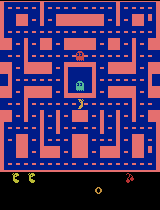

  Episode 301/2000 | 173,500 decisions | 43,126 updates | 14.9 min


Episode 301/2000 | score 640 | recent mean 734.0 | exploration 10%


  Episode 302/2000 | 174,000 decisions | 43,251 updates | 14.9 min


Episode 302/2000 | score 460 | recent mean 740.8 | exploration 10%


  Episode 303/2000 | 174,500 decisions | 43,376 updates | 15.0 min


...

Episode 324/2000 | score 1280 | recent mean 736.4 | exploration 10%


  Episode 325/2000 | 188,000 decisions | 46,751 updates | 16.2 min


  Episode 325/2000 | 188,500 decisions | 46,876 updates | 16.2 min


Episode 325/2000 | score 1250 | recent mean 766.4 | exploration 10%


Separate demonstration score: 430.0
After 325 training games | 4× playback | 2 plays | first 20s of game time


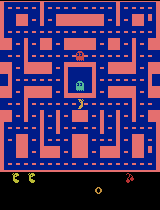

  Episode 326/2000 | 189,000 decisions | 47,001 updates | 16.3 min


Episode 326/2000 | score 510 | recent mean 761.2 | exploration 10%


  Episode 327/2000 | 189,500 decisions | 47,126 updates | 16.3 min


Episode 327/2000 | score 500 | recent mean 762.8 | exploration 10%


  Episode 328/2000 | 190,000 decisions | 47,251 updates | 16.4 min


...

  Episode 349/2000 | 203,000 decisions | 50,501 updates | 18.3 min


Episode 349/2000 | score 1420 | recent mean 872.8 | exploration 10%


  Episode 350/2000 | 203,500 decisions | 50,626 updates | 18.4 min


Episode 350/2000 | score 510 | recent mean 843.2 | exploration 10%


Separate demonstration score: 540.0
After 350 training games | 4× playback | 2 plays | first 20s of game time


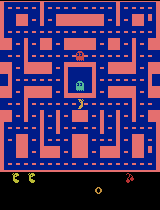

  Episode 351/2000 | 204,000 decisions | 50,751 updates | 18.5 min


Episode 351/2000 | score 340 | recent mean 836.4 | exploration 10%


  Episode 352/2000 | 204,500 decisions | 50,876 updates | 18.5 min


Episode 352/2000 | score 480 | recent mean 835.6 | exploration 10%


  Episode 353/2000 | 205,000 decisions | 51,001 updates | 18.5 min


...

Episode 374/2000 | score 520 | recent mean 852.0 | exploration 10%


  Episode 375/2000 | 218,500 decisions | 54,376 updates | 19.8 min


  Episode 375/2000 | 219,000 decisions | 54,501 updates | 19.8 min


Episode 375/2000 | score 1070 | recent mean 874.4 | exploration 10%


Separate demonstration score: 580.0
After 375 training games | 4× playback | 2 plays | first 20s of game time


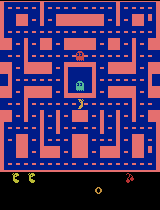

  Episode 376/2000 | 219,500 decisions | 54,626 updates | 19.9 min


Episode 376/2000 | score 890 | recent mean 896.4 | exploration 10%


  Episode 377/2000 | 220,000 decisions | 54,751 updates | 19.9 min


Episode 377/2000 | score 440 | recent mean 894.8 | exploration 10%


  Episode 378/2000 | 220,500 decisions | 54,876 updates | 20.0 min


...

  Episode 400/2000 | 235,500 decisions | 58,626 updates | 21.3 min


  Episode 400/2000 | 236,000 decisions | 58,751 updates | 21.4 min


Episode 400/2000 | score 890 | recent mean 926.0 | exploration 10%


Separate demonstration score: 990.0


After 400 training games | 4× playback | 2 plays | first 20s of game time


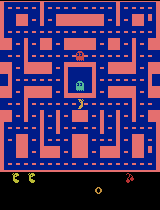

  Episode 401/2000 | 236,500 decisions | 58,876 updates | 21.4 min


Episode 401/2000 | score 880 | recent mean 925.6 | exploration 10%


  Episode 402/2000 | 237,000 decisions | 59,001 updates | 21.5 min


Episode 402/2000 | score 490 | recent mean 927.6 | exploration 10%


  Episode 403/2000 | 237,500 decisions | 59,126 updates | 21.5 min


...

  Episode 424/2000 | 250,000 decisions | 62,251 updates | 22.5 min


Episode 424/2000 | score 780 | recent mean 667.2 | exploration 10%


  Episode 425/2000 | 250,500 decisions | 62,376 updates | 22.5 min


Episode 425/2000 | score 920 | recent mean 668.4 | exploration 10%


Separate demonstration score: 1570.0
After 425 training games | 4× playback | 2 plays | first 20s of game time


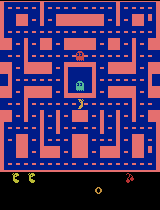

  Episode 426/2000 | 251,000 decisions | 62,501 updates | 22.6 min


Episode 426/2000 | score 410 | recent mean 649.6 | exploration 10%


  Episode 427/2000 | 251,500 decisions | 62,626 updates | 22.6 min


Episode 427/2000 | score 480 | recent mean 649.2 | exploration 10%


  Episode 428/2000 | 252,000 decisions | 62,751 updates | 22.7 min


...

  Episode 449/2000 | 265,500 decisions | 66,126 updates | 23.7 min


Episode 449/2000 | score 440 | recent mean 758.8 | exploration 10%


  Episode 450/2000 | 266,000 decisions | 66,251 updates | 23.7 min


Episode 450/2000 | score 560 | recent mean 744.4 | exploration 10%


Separate demonstration score: 770.0
After 450 training games | 4× playback | 2 plays | first 20s of game time


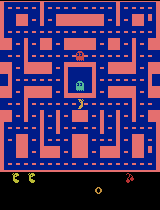

  Episode 451/2000 | 266,500 decisions | 66,376 updates | 23.8 min


  Episode 451/2000 | 267,000 decisions | 66,501 updates | 23.8 min


Episode 451/2000 | score 1690 | recent mean 795.6 | exploration 10%


  Episode 452/2000 | 267,500 decisions | 66,626 updates | 23.8 min


Episode 452/2000 | score 680 | recent mean 803.6 | exploration 10%


...

  Episode 474/2000 | 282,500 decisions | 70,376 updates | 25.0 min


Episode 474/2000 | score 500 | recent mean 928.4 | exploration 10%


  Episode 475/2000 | 283,000 decisions | 70,501 updates | 25.0 min


Episode 475/2000 | score 430 | recent mean 923.2 | exploration 10%


Separate demonstration score: 380.0
After 475 training games | 4× playback | 2 plays | first 20s of game time


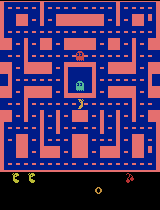

  Episode 476/2000 | 283,500 decisions | 70,626 updates | 25.1 min


Episode 476/2000 | score 460 | recent mean 874.0 | exploration 10%


  Episode 477/2000 | 284,000 decisions | 70,751 updates | 25.1 min


Episode 477/2000 | score 2260 | recent mean 937.2 | exploration 10%


  Episode 478/2000 | 284,500 decisions | 70,876 updates | 25.2 min


...

Episode 499/2000 | score 610 | recent mean 786.0 | exploration 10%


  Episode 500/2000 | 298,000 decisions | 74,251 updates | 26.5 min


  Episode 500/2000 | 298,500 decisions | 74,376 updates | 26.5 min


Episode 500/2000 | score 920 | recent mean 805.6 | exploration 10%


Separate demonstration score: 1060.0
After 500 training games | 4× playback | 2 plays | first 20s of game time


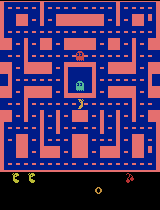

  Episode 501/2000 | 299,000 decisions | 74,501 updates | 26.6 min


Episode 501/2000 | score 510 | recent mean 807.6 | exploration 10%


  Episode 502/2000 | 299,500 decisions | 74,626 updates | 26.7 min


Episode 502/2000 | score 770 | recent mean 748.0 | exploration 10%


  Episode 503/2000 | 300,000 decisions | 74,751 updates | 26.7 min


...

  Episode 524/2000 | 314,000 decisions | 78,251 updates | 27.8 min


Episode 524/2000 | score 430 | recent mean 927.6 | exploration 10%


  Episode 525/2000 | 314,500 decisions | 78,376 updates | 27.9 min


Episode 525/2000 | score 460 | recent mean 909.2 | exploration 10%


Separate demonstration score: 1220.0
After 525 training games | 4× playback | 2 plays | first 20s of game time


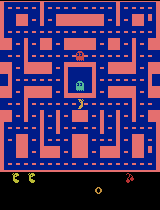

  Episode 526/2000 | 315,000 decisions | 78,501 updates | 27.9 min


Episode 526/2000 | score 770 | recent mean 919.6 | exploration 10%


  Episode 527/2000 | 315,500 decisions | 78,626 updates | 28.0 min


Episode 527/2000 | score 1430 | recent mean 946.0 | exploration 10%


  Episode 528/2000 | 316,000 decisions | 78,751 updates | 28.0 min


...

  Episode 549/2000 | 330,000 decisions | 82,251 updates | 29.4 min


Episode 549/2000 | score 1000 | recent mean 949.6 | exploration 10%


  Episode 550/2000 | 330,500 decisions | 82,376 updates | 29.5 min


Episode 550/2000 | score 660 | recent mean 957.6 | exploration 10%


Separate demonstration score: 480.0
After 550 training games | 4× playback | 2 plays | first 20s of game time


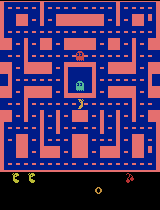

  Episode 551/2000 | 331,000 decisions | 82,501 updates | 29.5 min


Episode 551/2000 | score 790 | recent mean 958.4 | exploration 10%


  Episode 552/2000 | 331,500 decisions | 82,626 updates | 29.6 min


  Episode 552/2000 | 332,000 decisions | 82,751 updates | 29.6 min


Episode 552/2000 | score 780 | recent mean 932.4 | exploration 10%


...

Episode 574/2000 | score 770 | recent mean 1006.8 | exploration 10%


  Episode 575/2000 | 347,500 decisions | 86,626 updates | 30.9 min


  Episode 575/2000 | 348,000 decisions | 86,751 updates | 31.0 min


Episode 575/2000 | score 1280 | recent mean 1031.6 | exploration 10%


Separate demonstration score: 1220.0
After 575 training games | 4× playback | 2 plays | first 20s of game time


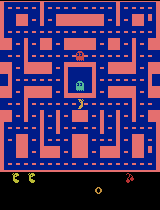

  Episode 576/2000 | 348,500 decisions | 86,876 updates | 31.1 min


Episode 576/2000 | score 480 | recent mean 1019.2 | exploration 10%


  Episode 577/2000 | 349,000 decisions | 87,001 updates | 31.2 min


Episode 577/2000 | score 900 | recent mean 1024.0 | exploration 10%


  Episode 578/2000 | 349,500 decisions | 87,126 updates | 31.2 min


...

Episode 599/2000 | score 1040 | recent mean 817.2 | exploration 10%


  Episode 600/2000 | 364,000 decisions | 90,751 updates | 32.8 min


Episode 600/2000 | score 730 | recent mean 795.2 | exploration 10%


Separate demonstration score: 930.0


After 600 training games | 4× playback | 2 plays | first 20s of game time


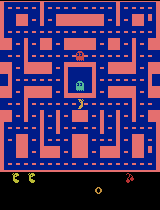

  Episode 601/2000 | 364,500 decisions | 90,876 updates | 32.9 min


Episode 601/2000 | score 470 | recent mean 794.8 | exploration 10%


  Episode 602/2000 | 365,000 decisions | 91,001 updates | 32.9 min


Episode 602/2000 | score 510 | recent mean 779.2 | exploration 10%


  Episode 603/2000 | 365,500 decisions | 91,126 updates | 33.0 min


...

  Episode 624/2000 | 379,500 decisions | 94,626 updates | 34.5 min


Episode 624/2000 | score 1110 | recent mean 935.2 | exploration 10%


  Episode 625/2000 | 380,000 decisions | 94,751 updates | 34.5 min


Episode 625/2000 | score 600 | recent mean 930.0 | exploration 10%


Separate demonstration score: 640.0
After 625 training games | 4× playback | 2 plays | first 20s of game time


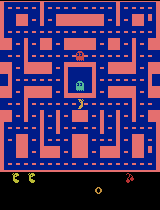

  Episode 626/2000 | 380,500 decisions | 94,876 updates | 34.6 min


  Episode 626/2000 | 381,000 decisions | 95,001 updates | 34.7 min


Episode 626/2000 | score 1430 | recent mean 968.4 | exploration 10%


  Episode 627/2000 | 381,500 decisions | 95,126 updates | 34.7 min


  Episode 627/2000 | 382,000 decisions | 95,251 updates | 34.7 min


...

Episode 649/2000 | score 940 | recent mean 888.8 | exploration 10%


  Episode 650/2000 | 397,000 decisions | 99,001 updates | 36.1 min


  Episode 650/2000 | 397,500 decisions | 99,126 updates | 36.2 min


Episode 650/2000 | score 690 | recent mean 892.4 | exploration 10%


Separate demonstration score: 1160.0
After 650 training games | 4× playback | 2 plays | first 20s of game time


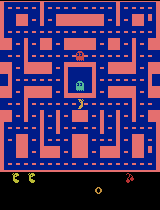

  Episode 651/2000 | 398,000 decisions | 99,251 updates | 36.2 min


Episode 651/2000 | score 970 | recent mean 874.0 | exploration 10%


  Episode 652/2000 | 398,500 decisions | 99,376 updates | 36.3 min


Episode 652/2000 | score 640 | recent mean 830.0 | exploration 10%


  Episode 653/2000 | 399,000 decisions | 99,501 updates | 36.4 min


...

Episode 674/2000 | score 1220 | recent mean 846.8 | exploration 10%


  Episode 675/2000 | 413,000 decisions | 103,001 updates | 37.7 min


  Episode 675/2000 | 413,500 decisions | 103,126 updates | 37.8 min


Episode 675/2000 | score 1170 | recent mean 866.0 | exploration 10%


Separate demonstration score: 570.0
After 675 training games | 4× playback | 2 plays | first 20s of game time


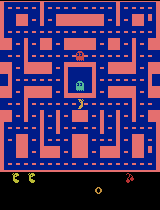

  Episode 676/2000 | 414,000 decisions | 103,251 updates | 37.8 min


Episode 676/2000 | score 760 | recent mean 857.6 | exploration 10%


  Episode 677/2000 | 414,500 decisions | 103,376 updates | 37.9 min


Episode 677/2000 | score 1250 | recent mean 882.0 | exploration 10%


  Episode 678/2000 | 415,000 decisions | 103,501 updates | 37.9 min


...

  Episode 699/2000 | 429,000 decisions | 107,001 updates | 39.1 min


Episode 699/2000 | score 1300 | recent mean 954.8 | exploration 10%


  Episode 700/2000 | 429,500 decisions | 107,126 updates | 39.1 min


Episode 700/2000 | score 810 | recent mean 940.4 | exploration 10%


Separate demonstration score: 590.0
After 700 training games | 4× playback | 2 plays | first 20s of game time


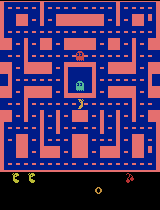

  Episode 701/2000 | 430,000 decisions | 107,251 updates | 39.2 min


Episode 701/2000 | score 420 | recent mean 926.8 | exploration 10%


  Episode 702/2000 | 430,500 decisions | 107,376 updates | 39.2 min


  Episode 702/2000 | 431,000 decisions | 107,501 updates | 39.3 min


Episode 702/2000 | score 1660 | recent mean 943.2 | exploration 10%


...

  Episode 724/2000 | 445,500 decisions | 111,126 updates | 40.7 min


Episode 724/2000 | score 700 | recent mean 980.0 | exploration 10%


  Episode 725/2000 | 446,000 decisions | 111,251 updates | 40.7 min


Episode 725/2000 | score 550 | recent mean 969.6 | exploration 10%


Separate demonstration score: 1200.0
After 725 training games | 4× playback | 2 plays | first 20s of game time


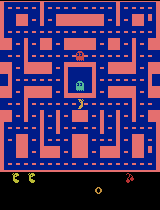

  Episode 726/2000 | 446,500 decisions | 111,376 updates | 40.8 min


  Episode 726/2000 | 447,000 decisions | 111,501 updates | 40.8 min


Episode 726/2000 | score 570 | recent mean 975.6 | exploration 10%


  Episode 727/2000 | 447,500 decisions | 111,626 updates | 40.9 min


Episode 727/2000 | score 920 | recent mean 946.0 | exploration 10%


...

Episode 749/2000 | score 1230 | recent mean 965.6 | exploration 10%


  Episode 750/2000 | 463,500 decisions | 115,626 updates | 42.3 min


Episode 750/2000 | score 1400 | recent mean 999.6 | exploration 10%


Separate demonstration score: 440.0


After 750 training games | 4× playback | 2 plays | first 20s of game time


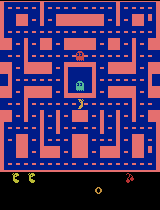

  Episode 751/2000 | 464,000 decisions | 115,751 updates | 42.4 min


  Episode 751/2000 | 464,500 decisions | 115,876 updates | 42.4 min


Episode 751/2000 | score 1420 | recent mean 1033.6 | exploration 10%


  Episode 752/2000 | 465,000 decisions | 116,001 updates | 42.5 min


Episode 752/2000 | score 610 | recent mean 1021.2 | exploration 10%


...

Episode 774/2000 | score 1020 | recent mean 1062.0 | exploration 10%


  Episode 775/2000 | 481,500 decisions | 120,126 updates | 43.7 min


  Episode 775/2000 | 482,000 decisions | 120,251 updates | 43.8 min


Episode 775/2000 | score 1200 | recent mean 1054.0 | exploration 10%


Separate demonstration score: 920.0
After 775 training games | 4× playback | 2 plays | first 20s of game time


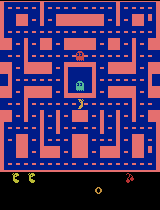

  Episode 776/2000 | 482,500 decisions | 120,376 updates | 43.8 min


Episode 776/2000 | score 330 | recent mean 1010.4 | exploration 10%


  Episode 777/2000 | 483,000 decisions | 120,501 updates | 43.8 min


Episode 777/2000 | score 730 | recent mean 1015.2 | exploration 10%


  Episode 778/2000 | 483,500 decisions | 120,626 updates | 43.9 min


...

  Episode 799/2000 | 497,000 decisions | 124,001 updates | 44.9 min


Episode 799/2000 | score 1290 | recent mean 821.2 | exploration 10%


  Episode 800/2000 | 497,500 decisions | 124,126 updates | 44.9 min


Episode 800/2000 | score 1020 | recent mean 814.0 | exploration 10%


Separate demonstration score: 2250.0
After 800 training games | 4× playback | 2 plays | first 20s of game time


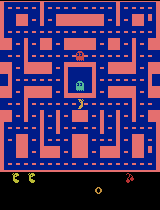

  Episode 801/2000 | 498,000 decisions | 124,251 updates | 45.0 min


  Episode 801/2000 | 498,500 decisions | 124,376 updates | 45.0 min


Episode 801/2000 | score 1280 | recent mean 852.0 | exploration 10%


  Episode 802/2000 | 499,000 decisions | 124,501 updates | 45.1 min


Episode 802/2000 | score 210 | recent mean 831.2 | exploration 10%


...

  Episode 824/2000 | 513,000 decisions | 128,001 updates | 46.0 min


Episode 824/2000 | score 1760 | recent mean 893.6 | exploration 10%


  Episode 825/2000 | 513,500 decisions | 128,126 updates | 46.1 min


Episode 825/2000 | score 1040 | recent mean 894.4 | exploration 10%


Separate demonstration score: 710.0
After 825 training games | 4× playback | 2 plays | first 20s of game time


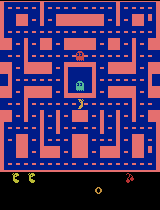

  Episode 826/2000 | 514,000 decisions | 128,251 updates | 46.1 min


Episode 826/2000 | score 420 | recent mean 860.0 | exploration 10%


  Episode 827/2000 | 514,500 decisions | 128,376 updates | 46.2 min


  Episode 827/2000 | 515,000 decisions | 128,501 updates | 46.2 min


Episode 827/2000 | score 770 | recent mean 882.4 | exploration 10%


...

  Episode 849/2000 | 530,000 decisions | 132,251 updates | 47.4 min


Episode 849/2000 | score 1990 | recent mean 1033.6 | exploration 10%


  Episode 850/2000 | 530,500 decisions | 132,376 updates | 47.4 min


Episode 850/2000 | score 1450 | recent mean 1050.0 | exploration 10%


Separate demonstration score: 970.0
After 850 training games | 4× playback | 2 plays | first 20s of game time


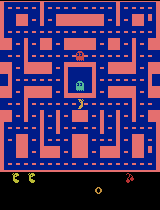

  Episode 851/2000 | 531,000 decisions | 132,501 updates | 47.5 min


Episode 851/2000 | score 540 | recent mean 1054.8 | exploration 10%


  Episode 852/2000 | 531,500 decisions | 132,626 updates | 47.5 min


Episode 852/2000 | score 290 | recent mean 1035.6 | exploration 10%


  Episode 853/2000 | 532,000 decisions | 132,751 updates | 47.6 min


...

  Episode 874/2000 | 547,000 decisions | 136,501 updates | 48.8 min


Episode 874/2000 | score 800 | recent mean 954.8 | exploration 10%


  Episode 875/2000 | 547,500 decisions | 136,626 updates | 48.8 min


Episode 875/2000 | score 1020 | recent mean 937.6 | exploration 10%


Separate demonstration score: 1010.0
After 875 training games | 4× playback | 2 plays | first 20s of game time


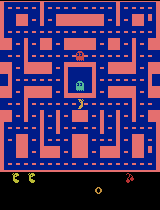

  Episode 876/2000 | 548,000 decisions | 136,751 updates | 48.9 min


  Episode 876/2000 | 548,500 decisions | 136,876 updates | 48.9 min


Episode 876/2000 | score 860 | recent mean 950.4 | exploration 10%


  Episode 877/2000 | 549,000 decisions | 137,001 updates | 48.9 min


Episode 877/2000 | score 910 | recent mean 975.2 | exploration 10%


...

  Episode 899/2000 | 568,000 decisions | 141,751 updates | 50.3 min


Episode 899/2000 | score 3270 | recent mean 1283.2 | exploration 10%


  Episode 900/2000 | 568,500 decisions | 141,876 updates | 50.3 min


Episode 900/2000 | score 1080 | recent mean 1285.6 | exploration 10%


Separate demonstration score: 590.0
After 900 training games | 4× playback | 2 plays | first 20s of game time


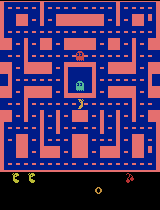

  Episode 901/2000 | 569,000 decisions | 142,001 updates | 50.4 min


Episode 901/2000 | score 930 | recent mean 1288.4 | exploration 10%


  Episode 902/2000 | 569,500 decisions | 142,126 updates | 50.4 min


Episode 902/2000 | score 1520 | recent mean 1312.8 | exploration 10%


  Episode 903/2000 | 570,000 decisions | 142,251 updates | 50.5 min


...

  Episode 924/2000 | 586,000 decisions | 146,251 updates | 51.9 min


Episode 924/2000 | score 970 | recent mean 1046.4 | exploration 10%


  Episode 925/2000 | 586,500 decisions | 146,376 updates | 52.0 min


Episode 925/2000 | score 690 | recent mean 1030.8 | exploration 10%


Separate demonstration score: 950.0
After 925 training games | 4× playback | 2 plays | first 20s of game time


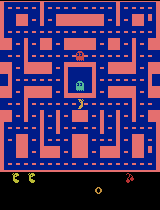

  Episode 926/2000 | 587,000 decisions | 146,501 updates | 52.1 min


Episode 926/2000 | score 410 | recent mean 1010.0 | exploration 10%


  Episode 927/2000 | 587,500 decisions | 146,626 updates | 52.1 min


  Episode 927/2000 | 588,000 decisions | 146,751 updates | 52.1 min


Episode 927/2000 | score 780 | recent mean 980.4 | exploration 10%


...

  Episode 949/2000 | 603,500 decisions | 150,626 updates | 53.5 min


Episode 949/2000 | score 1670 | recent mean 1109.2 | exploration 10%


  Episode 950/2000 | 604,000 decisions | 150,751 updates | 53.5 min


Episode 950/2000 | score 2110 | recent mean 1166.0 | exploration 10%


Separate demonstration score: 1770.0
After 950 training games | 4× playback | 2 plays | first 20s of game time


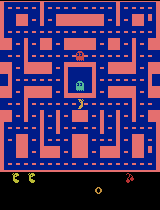

  Episode 951/2000 | 604,500 decisions | 150,876 updates | 53.6 min


  Episode 951/2000 | 605,000 decisions | 151,001 updates | 53.6 min


Episode 951/2000 | score 1220 | recent mean 1198.4 | exploration 10%


  Episode 952/2000 | 605,500 decisions | 151,126 updates | 53.6 min


Episode 952/2000 | score 410 | recent mean 1183.6 | exploration 10%


...

Episode 974/2000 | score 880 | recent mean 1147.2 | exploration 10%


  Episode 975/2000 | 621,000 decisions | 155,001 updates | 54.7 min


  Episode 975/2000 | 621,500 decisions | 155,126 updates | 54.7 min


Episode 975/2000 | score 620 | recent mean 1087.6 | exploration 10%


Separate demonstration score: 360.0
After 975 training games | 4× playback | 2 plays | first 20s of game time


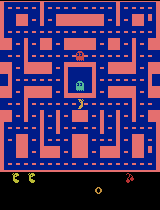

  Episode 976/2000 | 622,000 decisions | 155,251 updates | 54.8 min


Episode 976/2000 | score 820 | recent mean 1071.6 | exploration 10%


  Episode 977/2000 | 622,500 decisions | 155,376 updates | 54.8 min


  Episode 977/2000 | 623,000 decisions | 155,501 updates | 54.8 min


Episode 977/2000 | score 1270 | recent mean 1106.0 | exploration 10%


...

  Episode 999/2000 | 638,500 decisions | 159,376 updates | 55.9 min


Episode 999/2000 | score 2850 | recent mean 1038.0 | exploration 10%


  Episode 1000/2000 | 639,000 decisions | 159,501 updates | 55.9 min


Episode 1000/2000 | score 1740 | recent mean 1082.8 | exploration 10%


Separate demonstration score: 1080.0
After 1000 training games | 4× playback | 2 plays | first 20s of game time


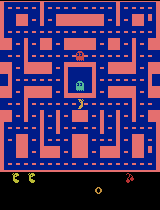

  Episode 1001/2000 | 639,500 decisions | 159,626 updates | 56.0 min


  Episode 1001/2000 | 640,000 decisions | 159,751 updates | 56.1 min


Episode 1001/2000 | score 1450 | recent mean 1108.0 | exploration 10%


  Episode 1002/2000 | 640,500 decisions | 159,876 updates | 56.1 min


Episode 1002/2000 | score 500 | recent mean 1077.2 | exploration 10%


...

Episode 1024/2000 | score 920 | recent mean 1191.2 | exploration 10%


  Episode 1025/2000 | 658,000 decisions | 164,251 updates | 57.5 min


  Episode 1025/2000 | 658,500 decisions | 164,376 updates | 57.5 min


Episode 1025/2000 | score 1350 | recent mean 1175.6 | exploration 10%


Separate demonstration score: 880.0
After 1025 training games | 4× playback | 2 plays | first 20s of game time


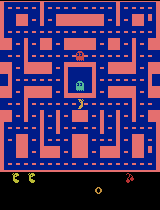

  Episode 1026/2000 | 659,000 decisions | 164,501 updates | 57.6 min


Episode 1026/2000 | score 1150 | recent mean 1163.6 | exploration 10%


  Episode 1027/2000 | 659,500 decisions | 164,626 updates | 57.6 min


  Episode 1027/2000 | 660,000 decisions | 164,751 updates | 57.7 min


Episode 1027/2000 | score 1500 | recent mean 1203.6 | exploration 10%


...

Episode 1049/2000 | score 1880 | recent mean 1139.2 | exploration 10%


  Episode 1050/2000 | 676,000 decisions | 168,751 updates | 59.2 min


  Episode 1050/2000 | 676,500 decisions | 168,876 updates | 59.3 min


Episode 1050/2000 | score 1200 | recent mean 1133.2 | exploration 10%


Separate demonstration score: 1000.0
After 1050 training games | 4× playback | 2 plays | first 20s of game time


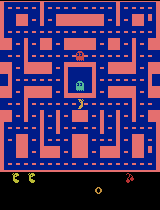

  Episode 1051/2000 | 677,000 decisions | 169,001 updates | 59.4 min


  Episode 1051/2000 | 677,500 decisions | 169,126 updates | 59.4 min


Episode 1051/2000 | score 1580 | recent mean 1150.4 | exploration 10%


  Episode 1052/2000 | 678,000 decisions | 169,251 updates | 59.5 min


  Episode 1052/2000 | 678,500 decisions | 169,376 updates | 59.5 min


...

  Episode 1074/2000 | 695,000 decisions | 173,501 updates | 61.1 min


Episode 1074/2000 | score 810 | recent mean 1105.2 | exploration 10%


  Episode 1075/2000 | 695,500 decisions | 173,626 updates | 61.1 min


Episode 1075/2000 | score 1070 | recent mean 1100.0 | exploration 10%


Separate demonstration score: 1400.0
After 1075 training games | 4× playback | 2 plays | first 20s of game time


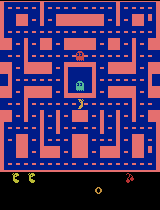

  Episode 1076/2000 | 696,000 decisions | 173,751 updates | 61.2 min


  Episode 1076/2000 | 696,500 decisions | 173,876 updates | 61.2 min


Episode 1076/2000 | score 1100 | recent mean 1080.8 | exploration 10%


  Episode 1077/2000 | 697,000 decisions | 174,001 updates | 61.2 min


Episode 1077/2000 | score 1160 | recent mean 1061.6 | exploration 10%


...

Episode 1099/2000 | score 900 | recent mean 1174.8 | exploration 10%


  Episode 1100/2000 | 714,500 decisions | 178,376 updates | 62.7 min


  Episode 1100/2000 | 715,000 decisions | 178,501 updates | 62.7 min


Episode 1100/2000 | score 2220 | recent mean 1220.8 | exploration 10%


Separate demonstration score: 820.0
After 1100 training games | 4× playback | 2 plays | first 20s of game time


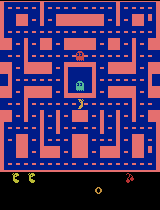

  Episode 1101/2000 | 715,500 decisions | 178,626 updates | 62.8 min


  Episode 1101/2000 | 716,000 decisions | 178,751 updates | 62.8 min


Episode 1101/2000 | score 1050 | recent mean 1218.8 | exploration 10%


  Episode 1102/2000 | 716,500 decisions | 178,876 updates | 62.8 min


Episode 1102/2000 | score 260 | recent mean 1182.8 | exploration 10%


...

  Episode 1124/2000 | 731,500 decisions | 182,626 updates | 64.1 min


Episode 1124/2000 | score 1490 | recent mean 1011.6 | exploration 10%


  Episode 1125/2000 | 732,000 decisions | 182,751 updates | 64.1 min


Episode 1125/2000 | score 950 | recent mean 960.8 | exploration 10%


Separate demonstration score: 820.0
After 1125 training games | 4× playback | 2 plays | first 20s of game time


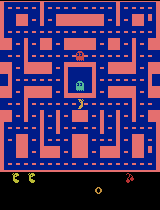

  Episode 1126/2000 | 732,500 decisions | 182,876 updates | 64.2 min


  Episode 1126/2000 | 733,000 decisions | 183,001 updates | 64.2 min


Episode 1126/2000 | score 1130 | recent mean 964.0 | exploration 10%


  Episode 1127/2000 | 733,500 decisions | 183,126 updates | 64.2 min


Episode 1127/2000 | score 2480 | recent mean 1052.8 | exploration 10%


...

Episode 1149/2000 | score 1290 | recent mean 1058.4 | exploration 10%


  Episode 1150/2000 | 749,500 decisions | 187,126 updates | 65.4 min


  Episode 1150/2000 | 750,000 decisions | 187,251 updates | 65.5 min


Episode 1150/2000 | score 1360 | recent mean 1074.8 | exploration 10%


Separate demonstration score: 1610.0
After 1150 training games | 4× playback | 2 plays | first 20s of game time


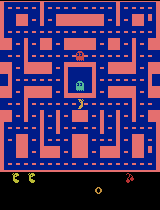

  Episode 1151/2000 | 750,500 decisions | 187,376 updates | 65.5 min


Episode 1151/2000 | score 870 | recent mean 1064.4 | exploration 10%


  Episode 1152/2000 | 751,000 decisions | 187,501 updates | 65.6 min


Episode 1152/2000 | score 1340 | recent mean 1018.8 | exploration 10%


Episode 1153/2000 | score 330 | recent mean 1011.2 | exploration 10%


...

Episode 1174/2000 | score 840 | recent mean 1186.8 | exploration 10%


  Episode 1175/2000 | 767,000 decisions | 191,501 updates | 66.8 min


  Episode 1175/2000 | 767,500 decisions | 191,626 updates | 66.8 min


Episode 1175/2000 | score 1880 | recent mean 1207.6 | exploration 10%


Separate demonstration score: 890.0
After 1175 training games | 4× playback | 2 plays | first 20s of game time


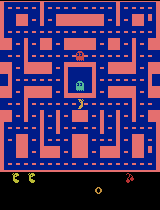

  Episode 1176/2000 | 768,000 decisions | 191,751 updates | 66.9 min


Episode 1176/2000 | score 930 | recent mean 1210.0 | exploration 10%


  Episode 1177/2000 | 768,500 decisions | 191,876 updates | 66.9 min


  Episode 1177/2000 | 769,000 decisions | 192,001 updates | 66.9 min


Episode 1177/2000 | score 1750 | recent mean 1226.4 | exploration 10%


...

  Episode 1199/2000 | 786,500 decisions | 196,376 updates | 68.3 min


Episode 1199/2000 | score 520 | recent mean 1261.6 | exploration 10%


  Episode 1200/2000 | 787,000 decisions | 196,501 updates | 68.3 min


Episode 1200/2000 | score 850 | recent mean 1220.4 | exploration 10%


Separate demonstration score: 1910.0
After 1200 training games | 4× playback | 2 plays | first 20s of game time


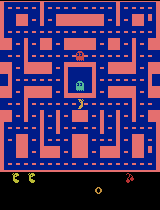

  Episode 1201/2000 | 787,500 decisions | 196,626 updates | 68.4 min


  Episode 1201/2000 | 788,000 decisions | 196,751 updates | 68.4 min


Episode 1201/2000 | score 1000 | recent mean 1223.2 | exploration 10%


  Episode 1202/2000 | 788,500 decisions | 196,876 updates | 68.5 min


Episode 1202/2000 | score 2170 | recent mean 1240.0 | exploration 10%


...

  Episode 1225/2000 | 805,000 decisions | 201,001 updates | 69.6 min


  Episode 1225/2000 | 805,500 decisions | 201,126 updates | 69.7 min


Episode 1225/2000 | score 1010 | recent mean 1068.4 | exploration 10%


Separate demonstration score: 2000.0


After 1225 training games | 4× playback | 2 plays | first 20s of game time


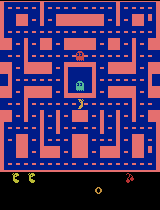

  Episode 1226/2000 | 806,000 decisions | 201,251 updates | 69.7 min


Episode 1226/2000 | score 1290 | recent mean 1080.0 | exploration 10%


  Episode 1227/2000 | 806,500 decisions | 201,376 updates | 69.8 min


  Episode 1227/2000 | 807,000 decisions | 201,501 updates | 69.8 min


Episode 1227/2000 | score 1890 | recent mean 1068.8 | exploration 10%


...

Episode 1249/2000 | score 410 | recent mean 973.2 | exploration 10%


  Episode 1250/2000 | 821,500 decisions | 205,126 updates | 70.7 min


  Episode 1250/2000 | 822,000 decisions | 205,251 updates | 70.8 min


Episode 1250/2000 | score 1000 | recent mean 972.8 | exploration 10%


Separate demonstration score: 630.0
After 1250 training games | 4× playback | 2 plays | first 20s of game time


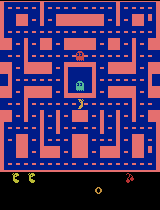

  Episode 1251/2000 | 822,500 decisions | 205,376 updates | 70.8 min


  Episode 1251/2000 | 823,000 decisions | 205,501 updates | 70.9 min


Episode 1251/2000 | score 2220 | recent mean 1010.0 | exploration 10%


  Episode 1252/2000 | 823,500 decisions | 205,626 updates | 70.9 min


  Episode 1252/2000 | 824,000 decisions | 205,751 updates | 70.9 min


...

  Episode 1274/2000 | 839,000 decisions | 209,501 updates | 72.1 min


Episode 1274/2000 | score 1570 | recent mean 1200.0 | exploration 10%


  Episode 1275/2000 | 839,500 decisions | 209,626 updates | 72.1 min


Episode 1275/2000 | score 460 | recent mean 1178.4 | exploration 10%


Separate demonstration score: 470.0
After 1275 training games | 4× playback | 2 plays | first 20s of game time


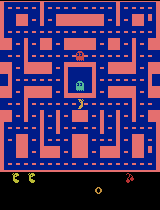

  Episode 1276/2000 | 840,000 decisions | 209,751 updates | 72.2 min


Episode 1276/2000 | score 1140 | recent mean 1135.2 | exploration 10%


  Episode 1277/2000 | 840,500 decisions | 209,876 updates | 72.2 min


  Episode 1277/2000 | 841,000 decisions | 210,001 updates | 72.3 min


Episode 1277/2000 | score 1370 | recent mean 1139.6 | exploration 10%


...

Episode 1299/2000 | score 1200 | recent mean 1230.4 | exploration 10%


  Episode 1300/2000 | 858,000 decisions | 214,251 updates | 73.4 min


  Episode 1300/2000 | 858,500 decisions | 214,376 updates | 73.5 min


Episode 1300/2000 | score 1080 | recent mean 1255.2 | exploration 10%


Separate demonstration score: 980.0
After 1300 training games | 4× playback | 2 plays | first 20s of game time


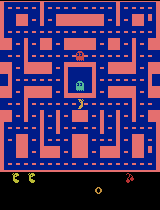

  Episode 1301/2000 | 859,000 decisions | 214,501 updates | 73.5 min


Episode 1301/2000 | score 770 | recent mean 1240.4 | exploration 10%


  Episode 1302/2000 | 859,500 decisions | 214,626 updates | 73.5 min


Episode 1302/2000 | score 1030 | recent mean 1226.8 | exploration 10%


  Episode 1303/2000 | 860,000 decisions | 214,751 updates | 73.6 min


...

  Episode 1324/2000 | 874,500 decisions | 218,376 updates | 74.6 min


Episode 1324/2000 | score 1430 | recent mean 1101.2 | exploration 10%


  Episode 1325/2000 | 875,000 decisions | 218,501 updates | 74.6 min


Episode 1325/2000 | score 1870 | recent mean 1132.8 | exploration 10%


Separate demonstration score: 1100.0
After 1325 training games | 4× playback | 2 plays | first 20s of game time


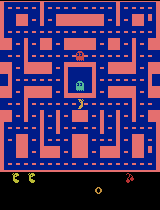

  Episode 1326/2000 | 875,500 decisions | 218,626 updates | 74.7 min


  Episode 1326/2000 | 876,000 decisions | 218,751 updates | 74.7 min


Episode 1326/2000 | score 1060 | recent mean 1144.4 | exploration 10%


  Episode 1327/2000 | 876,500 decisions | 218,876 updates | 74.7 min


Episode 1327/2000 | score 830 | recent mean 1136.4 | exploration 10%


...

Episode 1349/2000 | score 1060 | recent mean 993.2 | exploration 10%


  Episode 1350/2000 | 891,500 decisions | 222,626 updates | 75.8 min


  Episode 1350/2000 | 892,000 decisions | 222,751 updates | 75.8 min


Episode 1350/2000 | score 1730 | recent mean 987.6 | exploration 10%


Separate demonstration score: 1350.0
After 1350 training games | 4× playback | 2 plays | first 20s of game time


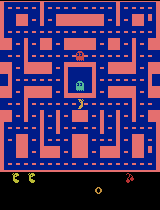

  Episode 1351/2000 | 892,500 decisions | 222,876 updates | 75.9 min


Episode 1351/2000 | score 1590 | recent mean 1008.8 | exploration 10%


  Episode 1352/2000 | 893,000 decisions | 223,001 updates | 75.9 min


  Episode 1352/2000 | 893,500 decisions | 223,126 updates | 75.9 min


Episode 1352/2000 | score 1110 | recent mean 1020.0 | exploration 10%


...

  Episode 1374/2000 | 909,000 decisions | 227,001 updates | 77.0 min


Episode 1374/2000 | score 1090 | recent mean 1123.2 | exploration 10%


  Episode 1375/2000 | 909,500 decisions | 227,126 updates | 77.0 min


Episode 1375/2000 | score 940 | recent mean 1091.6 | exploration 10%


Separate demonstration score: 960.0
After 1375 training games | 4× playback | 2 plays | first 20s of game time


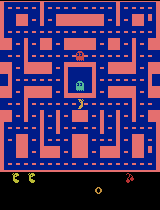

  Episode 1376/2000 | 910,000 decisions | 227,251 updates | 77.0 min


Episode 1376/2000 | score 950 | recent mean 1066.0 | exploration 10%


  Episode 1377/2000 | 910,500 decisions | 227,376 updates | 77.1 min


  Episode 1377/2000 | 911,000 decisions | 227,501 updates | 77.1 min


Episode 1377/2000 | score 560 | recent mean 1044.0 | exploration 10%


...

Episode 1399/2000 | score 1080 | recent mean 1093.6 | exploration 10%


  Episode 1400/2000 | 926,500 decisions | 231,376 updates | 78.2 min


  Episode 1400/2000 | 927,000 decisions | 231,501 updates | 78.3 min


Episode 1400/2000 | score 1490 | recent mean 1115.6 | exploration 10%


Separate demonstration score: 1200.0
After 1400 training games | 4× playback | 2 plays | first 20s of game time


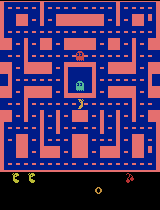

  Episode 1401/2000 | 927,500 decisions | 231,626 updates | 78.3 min


  Episode 1401/2000 | 928,000 decisions | 231,751 updates | 78.4 min


Episode 1401/2000 | score 1500 | recent mean 1137.6 | exploration 10%


  Episode 1402/2000 | 928,500 decisions | 231,876 updates | 78.4 min


  Episode 1402/2000 | 929,000 decisions | 232,001 updates | 78.4 min


...

  Episode 1424/2000 | 945,000 decisions | 236,001 updates | 79.5 min


Episode 1424/2000 | score 1720 | recent mean 1094.4 | exploration 10%


  Episode 1425/2000 | 945,500 decisions | 236,126 updates | 79.5 min


Episode 1425/2000 | score 850 | recent mean 1068.8 | exploration 10%


Separate demonstration score: 1810.0
After 1425 training games | 4× playback | 2 plays | first 20s of game time


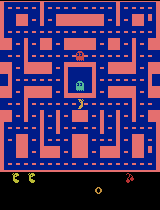

  Episode 1426/2000 | 946,000 decisions | 236,251 updates | 79.6 min


  Episode 1426/2000 | 946,500 decisions | 236,376 updates | 79.6 min


Episode 1426/2000 | score 1180 | recent mean 1056.0 | exploration 10%


  Episode 1427/2000 | 947,000 decisions | 236,501 updates | 79.7 min


Episode 1427/2000 | score 1450 | recent mean 1079.6 | exploration 10%


...

  Episode 1449/2000 | 963,500 decisions | 240,626 updates | 80.8 min


Episode 1449/2000 | score 1260 | recent mean 1208.4 | exploration 10%


  Episode 1450/2000 | 964,000 decisions | 240,751 updates | 80.8 min


Episode 1450/2000 | score 910 | recent mean 1210.8 | exploration 10%


Separate demonstration score: 1190.0
After 1450 training games | 4× playback | 2 plays | first 20s of game time


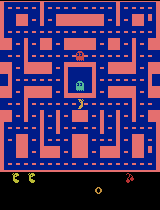

  Episode 1451/2000 | 964,500 decisions | 240,876 updates | 80.8 min


Episode 1451/2000 | score 480 | recent mean 1182.8 | exploration 10%


  Episode 1452/2000 | 965,000 decisions | 241,001 updates | 80.9 min


  Episode 1452/2000 | 965,500 decisions | 241,126 updates | 80.9 min


Episode 1452/2000 | score 1290 | recent mean 1176.4 | exploration 10%


...

  Episode 1474/2000 | 980,500 decisions | 244,876 updates | 81.9 min


Episode 1474/2000 | score 1080 | recent mean 989.2 | exploration 10%


  Episode 1475/2000 | 981,000 decisions | 245,001 updates | 82.0 min


Episode 1475/2000 | score 1020 | recent mean 993.6 | exploration 10%


Separate demonstration score: 990.0
After 1475 training games | 4× playback | 2 plays | first 20s of game time


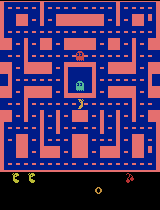

  Episode 1476/2000 | 981,500 decisions | 245,126 updates | 82.0 min


  Episode 1476/2000 | 982,000 decisions | 245,251 updates | 82.0 min


Episode 1476/2000 | score 1620 | recent mean 1039.2 | exploration 10%


  Episode 1477/2000 | 982,500 decisions | 245,376 updates | 82.1 min


Episode 1477/2000 | score 750 | recent mean 1017.6 | exploration 10%


...

Episode 1499/2000 | score 960 | recent mean 1136.8 | exploration 10%


  Episode 1500/2000 | 997,500 decisions | 249,126 updates | 83.1 min


  Episode 1500/2000 | 998,000 decisions | 249,251 updates | 83.2 min


Episode 1500/2000 | score 1200 | recent mean 1144.0 | exploration 10%


Separate demonstration score: 1520.0
After 1500 training games | 4× playback | 2 plays | first 20s of game time


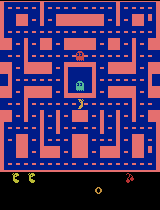

  Episode 1501/2000 | 998,500 decisions | 249,376 updates | 83.2 min


  Episode 1501/2000 | 999,000 decisions | 249,501 updates | 83.3 min


Episode 1501/2000 | score 1430 | recent mean 1136.4 | exploration 10%


  Episode 1502/2000 | 999,500 decisions | 249,626 updates | 83.3 min


  Episode 1502/2000 | 1,000,000 decisions | 249,751 updates | 83.3 min


...

  Episode 1524/2000 | 1,014,500 decisions | 253,376 updates | 84.3 min


  Episode 1524/2000 | 1,015,000 decisions | 253,501 updates | 84.4 min


Episode 1524/2000 | score 1850 | recent mean 1100.0 | exploration 10%


Episode 1525/2000 | score 420 | recent mean 1068.8 | exploration 10%


Separate demonstration score: 70.0
After 1525 training games | 4× playback | 2 plays | first 20s of game time


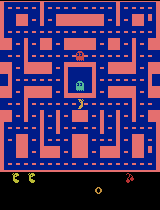

  Episode 1526/2000 | 1,015,500 decisions | 253,626 updates | 84.4 min


  Episode 1526/2000 | 1,016,000 decisions | 253,751 updates | 84.4 min


Episode 1526/2000 | score 1060 | recent mean 1054.0 | exploration 10%


  Episode 1527/2000 | 1,016,500 decisions | 253,876 updates | 84.5 min


Episode 1527/2000 | score 1020 | recent mean 1040.0 | exploration 10%


...

  Episode 1549/2000 | 1,032,500 decisions | 257,876 updates | 85.5 min


Episode 1549/2000 | score 1260 | recent mean 1196.8 | exploration 10%


  Episode 1550/2000 | 1,033,000 decisions | 258,001 updates | 85.6 min


Episode 1550/2000 | score 530 | recent mean 1201.2 | exploration 10%


Separate demonstration score: 1760.0
After 1550 training games | 4× playback | 2 plays | first 20s of game time


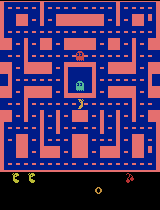

  Episode 1551/2000 | 1,033,500 decisions | 258,126 updates | 85.6 min


Episode 1551/2000 | score 860 | recent mean 1193.2 | exploration 10%


  Episode 1552/2000 | 1,034,000 decisions | 258,251 updates | 85.7 min


  Episode 1552/2000 | 1,034,500 decisions | 258,376 updates | 85.7 min


Episode 1552/2000 | score 680 | recent mean 1179.6 | exploration 10%


...

Episode 1574/2000 | score 810 | recent mean 983.6 | exploration 10%


  Episode 1575/2000 | 1,050,500 decisions | 262,376 updates | 86.8 min


  Episode 1575/2000 | 1,051,000 decisions | 262,501 updates | 86.8 min


Episode 1575/2000 | score 1030 | recent mean 1003.6 | exploration 10%


Separate demonstration score: 1400.0
After 1575 training games | 4× playback | 2 plays | first 20s of game time


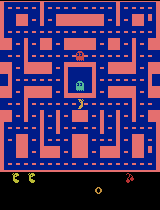

  Episode 1576/2000 | 1,051,500 decisions | 262,626 updates | 86.8 min


  Episode 1576/2000 | 1,052,000 decisions | 262,751 updates | 86.9 min


Episode 1576/2000 | score 1080 | recent mean 1012.4 | exploration 10%


  Episode 1577/2000 | 1,052,500 decisions | 262,876 updates | 86.9 min


  Episode 1577/2000 | 1,053,000 decisions | 263,001 updates | 86.9 min


...

  Episode 1599/2000 | 1,070,000 decisions | 267,251 updates | 88.0 min


Episode 1599/2000 | score 1720 | recent mean 1307.2 | exploration 10%


  Episode 1600/2000 | 1,070,500 decisions | 267,376 updates | 88.1 min


Episode 1600/2000 | score 700 | recent mean 1294.0 | exploration 10%


Separate demonstration score: 630.0
After 1600 training games | 4× playback | 2 plays | first 20s of game time


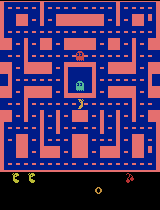

  Episode 1601/2000 | 1,071,000 decisions | 267,501 updates | 88.1 min


  Episode 1601/2000 | 1,071,500 decisions | 267,626 updates | 88.2 min


Episode 1601/2000 | score 1200 | recent mean 1298.8 | exploration 10%


  Episode 1602/2000 | 1,072,000 decisions | 267,751 updates | 88.2 min


  Episode 1602/2000 | 1,072,500 decisions | 267,876 updates | 88.2 min


...

Episode 1624/2000 | score 550 | recent mean 1244.8 | exploration 10%


  Episode 1625/2000 | 1,089,500 decisions | 272,126 updates | 89.4 min


  Episode 1625/2000 | 1,090,000 decisions | 272,251 updates | 89.4 min


Episode 1625/2000 | score 1060 | recent mean 1259.2 | exploration 10%


Separate demonstration score: 690.0
After 1625 training games | 4× playback | 2 plays | first 20s of game time


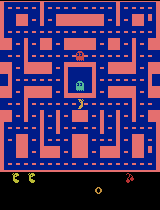

  Episode 1626/2000 | 1,090,500 decisions | 272,376 updates | 89.4 min


Episode 1626/2000 | score 790 | recent mean 1242.8 | exploration 10%


  Episode 1627/2000 | 1,091,000 decisions | 272,501 updates | 89.5 min


Episode 1627/2000 | score 820 | recent mean 1238.4 | exploration 10%


  Episode 1628/2000 | 1,091,500 decisions | 272,626 updates | 89.5 min


...

  Episode 1649/2000 | 1,105,000 decisions | 276,001 updates | 90.4 min


Episode 1649/2000 | score 660 | recent mean 944.8 | exploration 10%


  Episode 1650/2000 | 1,105,500 decisions | 276,126 updates | 90.4 min


Episode 1650/2000 | score 1180 | recent mean 949.6 | exploration 10%


Separate demonstration score: 730.0
After 1650 training games | 4× playback | 2 plays | first 20s of game time


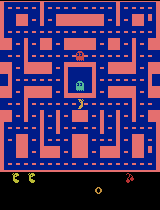

  Episode 1651/2000 | 1,106,000 decisions | 276,251 updates | 90.5 min


  Episode 1651/2000 | 1,106,500 decisions | 276,376 updates | 90.5 min


Episode 1651/2000 | score 780 | recent mean 949.2 | exploration 10%


  Episode 1652/2000 | 1,107,000 decisions | 276,501 updates | 90.6 min


Episode 1652/2000 | score 1520 | recent mean 977.2 | exploration 10%


...

  Episode 1674/2000 | 1,124,500 decisions | 280,876 updates | 91.7 min


Episode 1674/2000 | score 1110 | recent mean 1155.6 | exploration 10%


  Episode 1675/2000 | 1,125,000 decisions | 281,001 updates | 91.8 min


Episode 1675/2000 | score 430 | recent mean 1125.6 | exploration 10%


Separate demonstration score: 1170.0
After 1675 training games | 4× playback | 2 plays | first 20s of game time


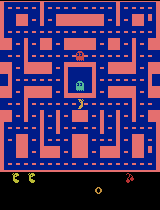

  Episode 1676/2000 | 1,125,500 decisions | 281,126 updates | 91.8 min


  Episode 1676/2000 | 1,126,000 decisions | 281,251 updates | 91.9 min


Episode 1676/2000 | score 1830 | recent mean 1167.6 | exploration 10%


  Episode 1677/2000 | 1,126,500 decisions | 281,376 updates | 91.9 min


Episode 1677/2000 | score 1150 | recent mean 1152.8 | exploration 10%


...

Episode 1699/2000 | score 1710 | recent mean 1200.8 | exploration 10%


  Episode 1700/2000 | 1,143,000 decisions | 285,501 updates | 93.0 min


  Episode 1700/2000 | 1,143,500 decisions | 285,626 updates | 93.0 min


Episode 1700/2000 | score 1140 | recent mean 1229.2 | exploration 10%


Separate demonstration score: 800.0
After 1700 training games | 4× playback | 2 plays | first 20s of game time


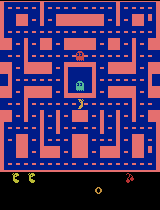

  Episode 1701/2000 | 1,144,000 decisions | 285,751 updates | 93.1 min


  Episode 1701/2000 | 1,144,500 decisions | 285,876 updates | 93.1 min


Episode 1701/2000 | score 2050 | recent mean 1238.0 | exploration 10%


  Episode 1702/2000 | 1,145,000 decisions | 286,001 updates | 93.1 min


  Episode 1702/2000 | 1,145,500 decisions | 286,126 updates | 93.2 min


...

  Episode 1724/2000 | 1,162,000 decisions | 290,251 updates | 94.2 min


Episode 1724/2000 | score 1000 | recent mean 1349.6 | exploration 10%


  Episode 1725/2000 | 1,162,500 decisions | 290,376 updates | 94.3 min


Episode 1725/2000 | score 610 | recent mean 1328.4 | exploration 10%


Separate demonstration score: 750.0
After 1725 training games | 4× playback | 2 plays | first 20s of game time


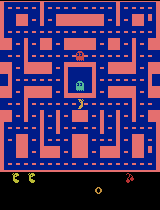

  Episode 1726/2000 | 1,163,000 decisions | 290,501 updates | 94.3 min


Episode 1726/2000 | score 910 | recent mean 1282.8 | exploration 10%


  Episode 1727/2000 | 1,163,500 decisions | 290,626 updates | 94.4 min


  Episode 1727/2000 | 1,164,000 decisions | 290,751 updates | 94.4 min


Episode 1727/2000 | score 1030 | recent mean 1274.4 | exploration 10%


...

  Episode 1749/2000 | 1,180,500 decisions | 294,876 updates | 95.5 min


Episode 1749/2000 | score 1310 | recent mean 1328.4 | exploration 10%


  Episode 1750/2000 | 1,181,000 decisions | 295,001 updates | 95.5 min


Episode 1750/2000 | score 800 | recent mean 1336.0 | exploration 10%


Separate demonstration score: 1520.0
After 1750 training games | 4× playback | 2 plays | first 20s of game time


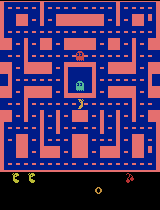

  Episode 1751/2000 | 1,181,500 decisions | 295,126 updates | 95.6 min


  Episode 1751/2000 | 1,182,000 decisions | 295,251 updates | 95.6 min


Episode 1751/2000 | score 1530 | recent mean 1360.8 | exploration 10%


  Episode 1752/2000 | 1,182,500 decisions | 295,376 updates | 95.6 min


Episode 1752/2000 | score 1120 | recent mean 1364.4 | exploration 10%


...

  Episode 1775/2000 | 1,199,500 decisions | 299,626 updates | 96.9 min


  Episode 1775/2000 | 1,200,000 decisions | 299,751 updates | 96.9 min


Episode 1775/2000 | score 1120 | recent mean 1102.0 | exploration 10%


Separate demonstration score: 640.0


After 1775 training games | 4× playback | 2 plays | first 20s of game time


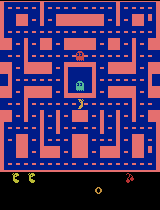

  Episode 1776/2000 | 1,200,500 decisions | 299,876 updates | 97.0 min


  Episode 1776/2000 | 1,201,000 decisions | 300,001 updates | 97.0 min


Episode 1776/2000 | score 1470 | recent mean 1099.6 | exploration 10%


  Episode 1777/2000 | 1,201,500 decisions | 300,126 updates | 97.0 min


Episode 1777/2000 | score 840 | recent mean 1088.4 | exploration 10%


...

Episode 1799/2000 | score 1190 | recent mean 1152.8 | exploration 10%


  Episode 1800/2000 | 1,218,000 decisions | 304,251 updates | 98.2 min


  Episode 1800/2000 | 1,218,500 decisions | 304,376 updates | 98.2 min


Episode 1800/2000 | score 1520 | recent mean 1168.8 | exploration 10%


Separate demonstration score: 1020.0
After 1800 training games | 4× playback | 2 plays | first 20s of game time


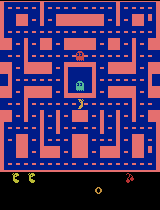

  Episode 1801/2000 | 1,219,000 decisions | 304,501 updates | 98.3 min


  Episode 1801/2000 | 1,219,500 decisions | 304,626 updates | 98.3 min


Episode 1801/2000 | score 830 | recent mean 1143.2 | exploration 10%


  Episode 1802/2000 | 1,220,000 decisions | 304,751 updates | 98.3 min


Episode 1802/2000 | score 790 | recent mean 1141.2 | exploration 10%


...

  Episode 1824/2000 | 1,238,000 decisions | 309,251 updates | 99.6 min


Episode 1824/2000 | score 1260 | recent mean 1168.4 | exploration 10%


  Episode 1825/2000 | 1,238,500 decisions | 309,376 updates | 99.6 min


Episode 1825/2000 | score 1100 | recent mean 1151.6 | exploration 10%


Separate demonstration score: 770.0
After 1825 training games | 4× playback | 2 plays | first 20s of game time


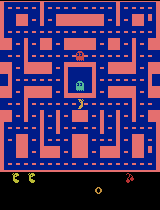

  Episode 1826/2000 | 1,239,000 decisions | 309,501 updates | 99.7 min


  Episode 1826/2000 | 1,239,500 decisions | 309,626 updates | 99.7 min


Episode 1826/2000 | score 1100 | recent mean 1162.4 | exploration 10%


  Episode 1827/2000 | 1,240,000 decisions | 309,751 updates | 99.7 min


Episode 1827/2000 | score 690 | recent mean 1158.4 | exploration 10%


...

Episode 1849/2000 | score 820 | recent mean 1095.2 | exploration 10%


  Episode 1850/2000 | 1,256,000 decisions | 313,751 updates | 100.9 min


  Episode 1850/2000 | 1,256,500 decisions | 313,876 updates | 100.9 min


Episode 1850/2000 | score 1170 | recent mean 1098.0 | exploration 10%


Separate demonstration score: 1070.0
After 1850 training games | 4× playback | 2 plays | first 20s of game time


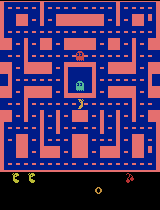

  Episode 1851/2000 | 1,257,000 decisions | 314,001 updates | 101.0 min


Episode 1851/2000 | score 1060 | recent mean 1096.4 | exploration 10%


  Episode 1852/2000 | 1,257,500 decisions | 314,126 updates | 101.0 min


  Episode 1852/2000 | 1,258,000 decisions | 314,251 updates | 101.0 min


Episode 1852/2000 | score 1010 | recent mean 1109.2 | exploration 10%


...

  Episode 1874/2000 | 1,275,500 decisions | 318,626 updates | 102.2 min


Episode 1874/2000 | score 2370 | recent mean 1346.4 | exploration 10%


  Episode 1875/2000 | 1,276,000 decisions | 318,751 updates | 102.2 min


Episode 1875/2000 | score 960 | recent mean 1338.0 | exploration 10%


Separate demonstration score: 2140.0
After 1875 training games | 4× playback | 2 plays | first 20s of game time


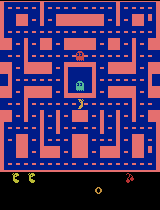

  Episode 1876/2000 | 1,276,500 decisions | 318,876 updates | 102.3 min


Episode 1876/2000 | score 1140 | recent mean 1341.2 | exploration 10%


  Episode 1877/2000 | 1,277,000 decisions | 319,001 updates | 102.3 min


  Episode 1877/2000 | 1,277,500 decisions | 319,126 updates | 102.3 min


Episode 1877/2000 | score 1350 | recent mean 1354.8 | exploration 10%


...

Episode 1899/2000 | score 1230 | recent mean 1224.8 | exploration 10%


  Episode 1900/2000 | 1,295,500 decisions | 323,626 updates | 103.5 min


  Episode 1900/2000 | 1,296,000 decisions | 323,751 updates | 103.6 min


Episode 1900/2000 | score 1130 | recent mean 1231.6 | exploration 10%


Separate demonstration score: 1340.0
After 1900 training games | 4× playback | 2 plays | first 20s of game time


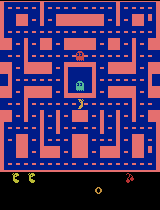

  Episode 1901/2000 | 1,296,500 decisions | 323,876 updates | 103.6 min


  Episode 1901/2000 | 1,297,000 decisions | 324,001 updates | 103.6 min


Episode 1901/2000 | score 1280 | recent mean 1237.2 | exploration 10%


  Episode 1902/2000 | 1,297,500 decisions | 324,126 updates | 103.7 min


Episode 1902/2000 | score 1470 | recent mean 1242.0 | exploration 10%


...

  Episode 1924/2000 | 1,313,500 decisions | 328,126 updates | 104.7 min


Episode 1924/2000 | score 680 | recent mean 1137.2 | exploration 10%


  Episode 1925/2000 | 1,314,000 decisions | 328,251 updates | 104.7 min


Episode 1925/2000 | score 550 | recent mean 1114.0 | exploration 10%


Separate demonstration score: 1200.0
After 1925 training games | 4× playback | 2 plays | first 20s of game time


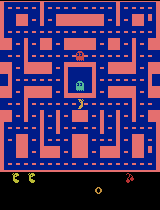

  Episode 1926/2000 | 1,314,500 decisions | 328,376 updates | 104.8 min


  Episode 1926/2000 | 1,315,000 decisions | 328,501 updates | 104.8 min


Episode 1926/2000 | score 1030 | recent mean 1104.0 | exploration 10%


  Episode 1927/2000 | 1,315,500 decisions | 328,626 updates | 104.9 min


Episode 1927/2000 | score 1240 | recent mean 1094.8 | exploration 10%


...

  Episode 1949/2000 | 1,331,500 decisions | 332,626 updates | 105.9 min


Episode 1949/2000 | score 1150 | recent mean 1194.0 | exploration 10%


  Episode 1950/2000 | 1,332,000 decisions | 332,751 updates | 105.9 min


Episode 1950/2000 | score 1000 | recent mean 1212.0 | exploration 10%


Separate demonstration score: 1170.0
After 1950 training games | 4× playback | 2 plays | first 20s of game time


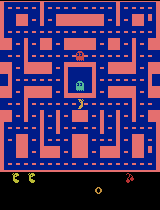

  Episode 1951/2000 | 1,332,500 decisions | 332,876 updates | 106.0 min


Episode 1951/2000 | score 1120 | recent mean 1215.6 | exploration 10%


  Episode 1952/2000 | 1,333,000 decisions | 333,001 updates | 106.0 min


  Episode 1952/2000 | 1,333,500 decisions | 333,126 updates | 106.0 min


Episode 1952/2000 | score 1460 | recent mean 1224.4 | exploration 10%


...

  Episode 1974/2000 | 1,350,500 decisions | 337,376 updates | 107.2 min


Episode 1974/2000 | score 970 | recent mean 1274.0 | exploration 10%


  Episode 1975/2000 | 1,351,000 decisions | 337,501 updates | 107.3 min


Episode 1975/2000 | score 990 | recent mean 1273.6 | exploration 10%


Separate demonstration score: 1110.0
After 1975 training games | 4× playback | 2 plays | first 20s of game time


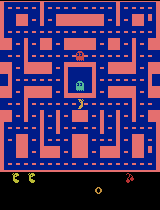

  Episode 1976/2000 | 1,351,500 decisions | 337,626 updates | 107.3 min


  Episode 1976/2000 | 1,352,000 decisions | 337,751 updates | 107.3 min


Episode 1976/2000 | score 820 | recent mean 1261.6 | exploration 10%


  Episode 1977/2000 | 1,352,500 decisions | 337,876 updates | 107.4 min


Episode 1977/2000 | score 900 | recent mean 1239.2 | exploration 10%


...

  Episode 1999/2000 | 1,369,000 decisions | 342,001 updates | 108.5 min


Episode 1999/2000 | score 740 | recent mean 1164.0 | exploration 10%


  Episode 2000/2000 | 1,369,500 decisions | 342,126 updates | 108.5 min


Episode 2000/2000 | score 770 | recent mean 1155.2 | exploration 10%


Separate demonstration score: 1010.0
After 2000 training games | 4× playback | 2 plays | first 20s of game time


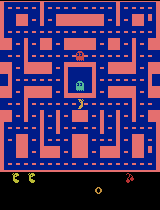

Saved: pacman_runs/20260914_184408_480922


In [25]:
if _training_started:
    raise RuntimeError("Start a new experiment by rerunning from section 5a, or use Run All.")
_training_started = True
train_env = make_env()
started = time.monotonic()
status = "completed"
try:
    for episode in range(1, EPISODES + 1):
        row = train_one_episode(train_env, episode)
        history.append(row)
        completed_episodes = episode
        recent_mean = np.mean([game["score"] for game in history[-25:]])
        print(f"Episode {episode}/{EPISODES} | score {row['score']:.0f} | "
              f"recent mean {recent_mean:.1f} | exploration {row['exploration']:.0%}", flush=True)
        save_metrics(history, RUN_DIR / "training.csv")
        if episode % DEMO_EVERY == 0:
            save_progress_sample(episode)
except KeyboardInterrupt:
    status = "interrupted"
    print("Stopped early. Saving your agent; continue to section 6 for results.")
except Exception:
    status = "failed"
    raise
finally:
    train_env.close()
    save_training_result(status)
print("Saved:", RUN_DIR)
if updates == 0:
    print("No learning updates yet: this run ended before a training batch was ready.")

## 6. did it learn?

Compare all five games under the same settings. The highlighted GIF is the best of these five trained games;
it is an illustration, not the evidence by itself. Five games give a small comparison, not a reliable research estimate.

### 6a. play the saved agent

Reload the checkpoint and play the same five evaluation seeds. This tests both the saved file and the agent’s behavior.

### 6a-i. choose which saved network to report (held-out seeds)

This notebook normally reports the **final** weights. Because exploration never decays, a long run
can peak partway through and drift afterwards, so the final network is not necessarily the best one.

This cell picks the checkpoint to report using **five held-out seeds that are deliberately different
from `EVAL_SEEDS`**. Everything else matches evaluation exactly: 5% exploration and the same
3,000-decision cap. Because the five reported seeds are never used to make the choice, the
before/after comparison below remains a fair estimate rather than a number tuned on its own test set.

The untrained network is not a candidate: the baseline must stay the untrained network.


In [26]:
# Model selection on seeds that are NOT the reported five.
HOLDOUT_SEEDS = [1001, 2002, 3003, 4004, 5005]
assert not set(HOLDOUT_SEEDS) & set(EVAL_SEEDS), "Held-out seeds must not overlap EVAL_SEEDS."

candidates = sorted(RUN_DIR.glob("episode_*.pt")) + [RUN_DIR / "trained.pt"]
selection = []
for path in candidates:
    saved = torch.load(path, map_location="cpu", weights_only=True)
    probe = DQN(saved["n_actions"]).to(DEVICE)
    probe.load_state_dict(saved["model"])
    scored = evaluate(probe, HOLDOUT_SEEDS)
    selection.append({"checkpoint": path.name, "episode": saved["episode"],
                      "holdout_scores": scored["scores"], "holdout_mean": scored["mean"]})
    print(f"{path.name:>18} | episode {saved['episode']:>5} | held-out mean {scored['mean']:8.1f}", flush=True)

best = max(selection, key=lambda row: row["holdout_mean"])
SELECTED_CHECKPOINT = RUN_DIR / best["checkpoint"]
(RUN_DIR / "checkpoint_selection.json").write_text(json.dumps(
    {"holdout_seeds": HOLDOUT_SEEDS, "reported_eval_seeds": EVAL_SEEDS,
     "eval_exploration": EVAL_EXPLORATION, "selected": best,
     "all_candidates": selection}, indent=2))
print(f"\nSelected {best['checkpoint']} (after {best['episode']} training games), "
      f"held-out mean {best['holdout_mean']:.1f} over {len(selection)} checkpoints.")

   episode_0025.pt | episode    25 | held-out mean    400.0


   episode_0050.pt | episode    50 | held-out mean    540.0


   episode_0075.pt | episode    75 | held-out mean    764.0


   episode_0100.pt | episode   100 | held-out mean    414.0


   episode_0125.pt | episode   125 | held-out mean    472.0


...

   episode_1950.pt | episode  1950 | held-out mean   1276.0


   episode_1975.pt | episode  1975 | held-out mean   1094.0


   episode_2000.pt | episode  2000 | held-out mean   1302.0


        trained.pt | episode  2000 | held-out mean   1302.0



Selected episode_1575.pt (after 1575 training games), held-out mean 1660.0 over 81 checkpoints.


In [27]:
# Load the saved model so the evaluation also verifies checkpoint playback.
checkpoint = torch.load(SELECTED_CHECKPOINT, map_location="cpu", weights_only=True)
trained_model = DQN(checkpoint["n_actions"]).to(DEVICE)
trained_model.load_state_dict(checkpoint["model"])
print(f"Evaluating {SELECTED_CHECKPOINT.name} on the same five games...", flush=True)
after = evaluate(trained_model, EVAL_SEEDS, RUN_DIR / "demos" / "final_best.gif", record_best=True)

Evaluating episode_1575.pt on the same five games...


### 6b. compare all five scores

Positive change means a higher average in this small test. A short run can get worse, and one good-looking sample is not enough to claim improvement.

  Game     Before      After
     1        350       1400
     2        500       1740
     3        320       1240
     4        800       1510
     5        490        910
  Mean      492.0     1360.0
Change in mean score: +868.0
Time-limited games before / after: 0 / 0


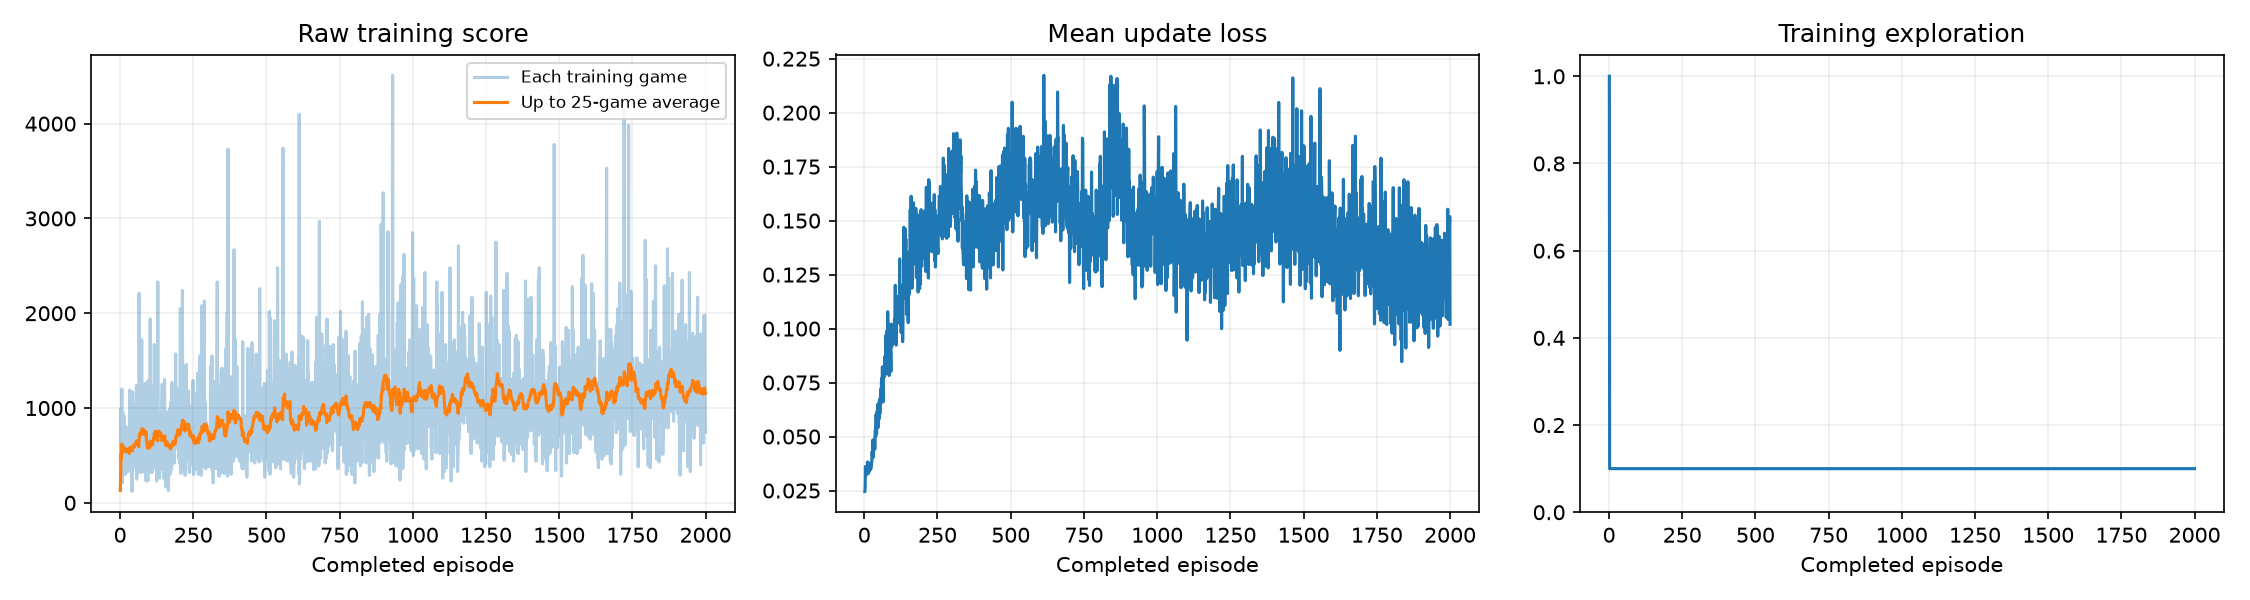

Final saved agent | 4× playback | 2 plays | first 20s of game time


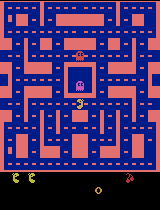

In [28]:
comparison = {"baseline_kind": "untrained network", "before": baseline, "after": after,
              "evaluation_exploration": EVAL_EXPLORATION, "max_decisions_per_game": MAX_STEPS}
(RUN_DIR / "comparison.json").write_text(json.dumps(comparison, indent=2))
print(f"{'Game':>6} {'Before':>10} {'After':>10}")
for game, (before_score, after_score) in enumerate(zip(baseline["scores"], after["scores"]), 1):
    print(f"{game:>6} {before_score:>10.0f} {after_score:>10.0f}")
print(f"{'Mean':>6} {baseline['mean']:>10.1f} {after['mean']:>10.1f}")
print(f"Change in mean score: {after['mean'] - baseline['mean']:+.1f}")
print("Time-limited games before / after:", sum(baseline["time_limited"]), "/", sum(after["time_limited"]))
display(Image(filename=str(RUN_DIR / "training_dashboard.png")))
show_sample(RUN_DIR / "demos" / "final_best.gif", "Final saved agent")

## 7. save and explain your experiment

The next cell creates a ZIP containing your settings, package versions, all evaluation scores, training log,
plot, GIFs, and playback checkpoints. In Colab, download it before ending the session.
To try another setting, change the three choices and run all cells again; that starts from scratch.

Keep the notebook, plot, selected GIFs, comparison, and your explanation in your GitHub submission.
Model checkpoints can make repositories large; keep them locally or attach them to a GitHub release.

In [29]:
archive = shutil.make_archive(str(RUN_DIR), "zip", root_dir=RUN_DIR)
try:
    from google.colab import files
except ImportError:
    display(FileLink(archive, result_html_prefix="Download your experiment: "))
else:
    files.download(archive)
print("Results folder:", RUN_DIR.resolve())

/Users/adityasankar/code/AgenticAI/pacman-dqn-class3/pacman_runs/20260914_184408_480922.zip

Results folder: /Users/adityasankar/code/AgenticAI/pacman-dqn-class3/pacman_runs/20260914_184408_480922


### your explanation

- **My choices:** exploration = __, episodes = __, learning rate = __.
- **My prediction:** I expected these settings to __ because __.
- **What happened:** mean score before = __; after = __. In the gameplay, I noticed __.
- **One limitation:** __.
- **My next experiment:** change only __ to __ and keep the other two settings fixed.

The agent observes four screens, chooses a joystick action, and receives game rewards.
Lower training loss does not necessarily mean a higher game score. Report lack of progress if that is what happened.

### implementation notes and sources

This is a small, readable DQN experiment, not a reproduction of a large Atari benchmark.
Replay is deliberately small for laptops. Epsilon stays constant after warm-up. Checkpoints support playback;
rerunning starts a new experiment, rather than resuming the optimizer, replay memory, or an interrupted game.
GPU results can vary even with fixed seeds.

- [ALE installation and Gymnasium registration](https://ale.farama.org/getting-started/)
- [Gymnasium Atari preprocessing](https://gymnasium.farama.org/api/wrappers/misc_wrappers/#gymnasium.wrappers.AtariPreprocessing)
- [Gymnasium frame stacking](https://gymnasium.farama.org/api/wrappers/observation_wrappers/#gymnasium.wrappers.FrameStackObservation)
- [DQN paper: Human-level control through deep reinforcement learning](https://storage.googleapis.com/deepmind-media/dqn/DQNNaturePaper.pdf)